# Multi-GPU Analysis on Inference Performance
Using Llama 3.1-8B on shy-fec (8 x A100, NVLink) and funnotch (4 x V100, PCIe)

### Imports & Setup


In [255]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.image as mpimage
import numpy as np
from io import BytesIO

from plot_utils import *

set_figure_style()

### Data Loading

In [256]:
multigpu_path = "../results/multi-gpu/concurrency-sweep/averaged_concurrency_sweep.csv"
singlegpu_path = "../results/single-gpu/concurrency-sweep/fine-grained/averaged_concurrency_sweep_fine_grained_results.csv"

multigpu_data= pd.read_csv(multigpu_path)
singlegpu_data= pd.read_csv(singlegpu_path)
singlegpu_data = singlegpu_data[singlegpu_data['max_concurrency'] > 1]

derived_metrics_path = "../results/multi-gpu/concurrency-sweep/derived_metrics.csv"
derived = pd.read_csv(derived_metrics_path)
derived = derived[derived['max_concurrency'] > 1]

### Preprocessing
Filter all dataframes to sort data by gpu and experiment type.

In [257]:
def filter_df(df, col, val):
    return df[df[col] == val].copy()

# filter csv for a100 configs
tp1_a100_df = filter_df(singlegpu_data, 'gpu_type', 'a100')
multigpu_a100 = filter_df(multigpu_data, 'gpu_type', 'a100')
tp2_a100_df = filter_df(multigpu_a100, 'label', 'mainsweep')
tp2_a100_nwfb_df = filter_df(multigpu_a100, 'label', 'networkfallback')
tp2_a100_shm_df = filter_df(multigpu_a100, 'label', 'p2pdisabled')
tp4_a100_df = filter_df(multigpu_a100, 'label', 'mainsweep_tp4')

# filter csv for v100 data
tp1_v100_df = filter_df(singlegpu_data, 'gpu_type', 'v100')
multigpu_v100 = filter_df(multigpu_data, 'gpu_type', 'v100')
tp2_v100_df = filter_df(multigpu_v100, 'label', 'mainsweep')
tp2_v100_nwfb_df = filter_df(multigpu_v100, 'label', 'networkfallback')
tp2_v100_shm_df = filter_df(multigpu_v100, 'label', 'p2pdisabled')
tp4_v100_df = filter_df(multigpu_v100, 'label', 'mainsweep_tp4')

# filter derived metrics for gpu data
derived_a100 = filter_df(derived, 'gpu_type', 'a100')
derived_v100 = filter_df(derived, 'gpu_type', 'v100')


### KV Cache Saturation
Using Llama 3.1-8B model specifics and formula for KV cache allocation size and how much memory a request would take up, we can calculate at what number of concurrent users the KV cache would saturate.

This is important because near saturation, model performance tends to have maximum throughput, but once number of concurrent requests exceeds this, we see degradation of performance. 

In [258]:

# constants for llama 3.1 8B
_KV_NUM_LAYERS   = 32
_KV_NUM_KV_HEADS = 8
_KV_HEAD_DIM     = 128
_KV_DTYPE_BYTES  = 2    # bf16

def kv_per_request_gb(isl=512, osl=512):
    """ kv cache memory (GB) of one request at mid-decode """
    avg_tokens = isl + osl / 2
    return (2 * _KV_NUM_LAYERS * avg_tokens * _KV_NUM_KV_HEADS
            * _KV_HEAD_DIM * _KV_DTYPE_BYTES) / 1e9

def kv_allocated_gb(
        total_vram, gpu_mem_util, weight_gb=16.0, activation_frac=0.1):
    """ estimated allocated available kv cache size (GB) """
    return total_vram * gpu_mem_util - weight_gb - total_vram * activation_frac

def kv_saturation_point(
        total_vram, gpu_mem_util, isl=512, osl=512, weight_gb=16.0, activation_frac=0.1):
    """ estimated analytical concurrency where kv cache is saturated """
    reserved_kv_gb = kv_allocated_gb(
        total_vram, gpu_mem_util, weight_gb, activation_frac)
    return reserved_kv_gb / kv_per_request_gb(isl, osl)

# compute saturation lines
tp1_a100_saturation = kv_saturation_point(40, 0.85)
tp1_v100_saturation = kv_saturation_point(32, 0.85)

tp2_a100_saturation = kv_saturation_point(80, 0.85)
tp2_v100_saturation = kv_saturation_point(64, 0.85)

tp4_a100_saturation = kv_saturation_point(160, 0.85)
tp4_v100_saturation = kv_saturation_point(128, 0.85)

print(f"AT TP=1: \n    A100 saturation point: {tp1_a100_saturation:.0f}")
print(f"    V100 saturation point: {tp1_v100_saturation:.0f}\n")
print(f"AT TP=2: \n    A100 saturation point: {tp2_a100_saturation:.0f}")
print(f"    V100 saturation point: {tp2_v100_saturation:.0f}\n")
print(f"AT TP=4: \n    A100 saturation point: {tp4_a100_saturation:.0f}")
print(f"    V100 saturation point: {tp4_v100_saturation:.0f}")



AT TP=1: 
    A100 saturation point: 139
    V100 saturation point: 79

AT TP=2: 
    A100 saturation point: 437
    V100 saturation point: 318

AT TP=4: 
    A100 saturation point: 1033
    V100 saturation point: 795


## A100 Results (shy-fec)

In [259]:
def plot_metric_vs_concurrency(
    dfs, metric, ylabel, title, labels, colors,
    saturation_lines=None,
    log_scale=None,
    y_lim=None,
    subtitle_info=None,
    paper=False,
):
    fig, ax = plt.subplots()

    for df, label, color in zip(dfs, labels, colors):
        ax.plot(df['max_concurrency'], df[metric], marker='o', 
                label=label, markersize=2, color=color)
    if y_lim != None:
        ax.set_ylim(y_lim[0], y_lim[1])

    if saturation_lines:
        ylim = ax.get_ylim()
        for x_val, sat_label in saturation_lines:
            ax.axvline(x=x_val, color='grey', linewidth=0.9, linestyle=':')
 
    ax.set_title(title, pad=15)
    ax.set_xlabel('Concurrency')
    ax.set_ylabel(ylabel)
    ax.set_xticks(df['max_concurrency'])
    ax.set_xscale('log', base=2)
    if log_scale:
        ax.set_yscale('log', base=2)
        ticks_s = [0.1, 1, 10, 60]
        ticks_ms = 1000 * np.array(ticks_s)
        ax.set_yticks(ticks_ms)
        ax.set_yticklabels([f"{t}s" for t in ticks_s])
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(fontsize=7)
    if subtitle_info and not paper:
        subtitle(ax, **subtitle_info)
    plt.tight_layout()
    return fig

def show_side_by_side(*figs, titles=None, figsize=None):
    """ display multiple matplotlib figures side by side in the notebook """
    n = len(figs)
    fw, fh = (figs[0].get_size_inches())
    figsize = figsize or (fw * n + 0.5 * (n - 1), fh)

    composite, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]

    for ax, fig, title in zip(axes, figs, titles or [None] * n):
        buf = BytesIO()
        fig.savefig(buf, format='png', dpi=fig.dpi, bbox_inches='tight')
        buf.seek(0)
        img = mpimage.imread(buf)
        ax.imshow(img)
        ax.axis('off')
        if title:
            ax.set_title(title, fontsize=9)
        plt.close(fig)  # close the original to free memory

    plt.tight_layout(pad=0.3)
    plt.show()

### Tensor Parallelism (TP) Scaling

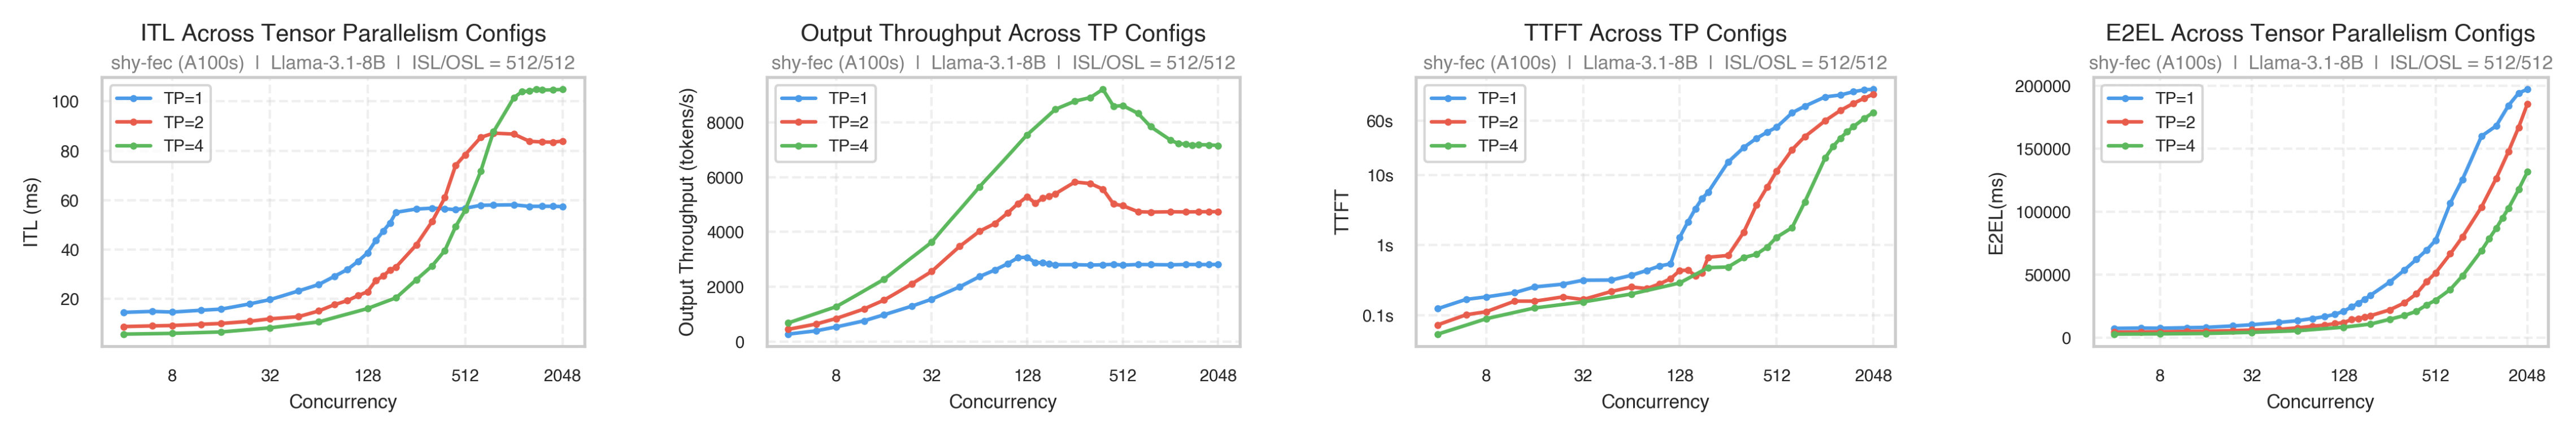

In [260]:
sub = dict(gpu='shy-fec (A100s)', model='Llama-3.1-8B', config='ISL/OSL = 512/512')

fig_itl = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp4_a100_df],
    metric="mean_itl_ms",
    ylabel="ITL (ms)",
    title="ITL Across Tensor Parallelism Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub
)
fig_thp = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp4_a100_df],
    metric="output_throughput",
    ylabel="Output Throughput (tokens/s)",
    title="Output Throughput Across TP Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub
)
fig_ttft = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp4_a100_df],
    metric="mean_ttft_ms",
    ylabel="TTFT",
    title="TTFT Across TP Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    log_scale=True,
    subtitle_info=sub
)
fig_e2el = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp4_a100_df],
    metric="mean_e2el_ms",
    ylabel="E2EL(ms)",
    title="E2EL Across Tensor Parallelism Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub
)
show_side_by_side(fig_itl, fig_thp, fig_ttft, fig_e2el)

### Interconnect Comparison: NVLink vs SHM vs Socket (TP=2)

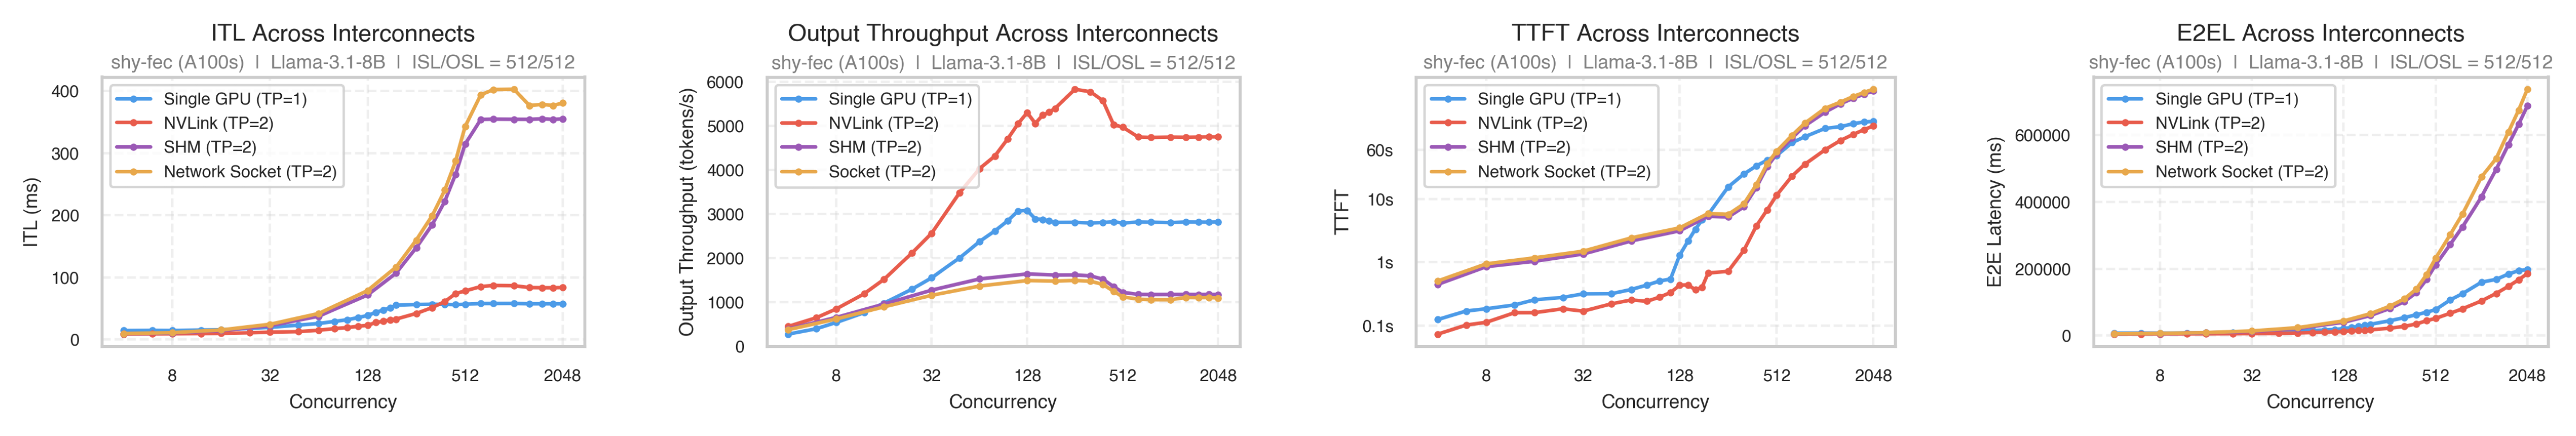

In [261]:

sub = dict(gpu='shy-fec (A100s)', model='Llama-3.1-8B', config='ISL/OSL = 512/512')

fig_thp = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp2_a100_shm_df, tp2_a100_nwfb_df],
    metric="output_throughput",
    ylabel="Output Throughput (tokens/s)",
    title="Output Throughput Across Interconnects",
    labels=["Single GPU (TP=1)", "NVLink (TP=2)", "SHM (TP=2)", "Socket (TP=2)"],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C"],
    subtitle_info=sub,
)

fig_itl = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp2_a100_shm_df, tp2_a100_nwfb_df],
    metric="mean_itl_ms",
    ylabel="ITL (ms)",
    title="ITL Across Interconnects",
    labels=["Single GPU (TP=1)", "NVLink (TP=2)", "SHM (TP=2)", "Network Socket (TP=2)"],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C"],
    subtitle_info=sub,
)

fig_e2el = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp2_a100_shm_df, tp2_a100_nwfb_df],
    metric="mean_e2el_ms",
    ylabel="E2E Latency (ms)",
    title="E2EL Across Interconnects",
    labels=["Single GPU (TP=1)", "NVLink (TP=2)", "SHM (TP=2)", "Network Socket (TP=2)"],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C"],
    subtitle_info=sub,
)

fig_ttft = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp2_a100_shm_df, tp2_a100_nwfb_df],
    metric="mean_ttft_ms",
    ylabel="TTFT",
    title="TTFT Across Interconnects",
    labels=["Single GPU (TP=1)", "NVLink (TP=2)", "SHM (TP=2)", "Network Socket (TP=2)"],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C"],
    log_scale=True,
    subtitle_info=sub,
)
show_side_by_side(fig_itl, fig_thp, fig_ttft, fig_e2el)

### Scaling Efficiency
Taking a look at throughput efficiency, normalized output throughput and speed-up of latency metrics when scaling across multiple GPUs.

In [262]:

def plot_throughput_efficiency(
        df, title, labels, legend_labels,
        subtitle_info=None, 
        paper=False):
    
    fig, ax = plt.subplots(figsize=(4,3))
    colors = ["#E85C4C", "#9B59B6", "#E8A84C", "#5CB85C"]

    for label, legend_label, color in zip(labels, legend_labels, colors):
        filtered_df = filter_df(df, 'label', label)
        ax.plot(filtered_df['max_concurrency'], 
                filtered_df['throughput_efficiency'],
                color=color, label=legend_label)

    ax.axhline(1.0, color='#444444', linewidth=0.8, linestyle='--')
    ax.text(7, 1.02, "ideal (efficiency = 1)", size=6)
    ax.set_title(title, pad=25)
    ax.set_xlabel('Concurrency')
    ax.set_ylabel('Efficiency')
    ax.set_xticks(df['max_concurrency'])
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(fontsize=7, loc='best')
    ax.legend(loc='lower center', bbox_to_anchor=(1.02, 0.07), 
              title='Configuration')
    if subtitle_info and not paper:
        subtitle(ax, **subtitle_info)
    plt.tight_layout()
    return fig

def plot_relative_speedup(
    df, title, metric, 
    labels, legend_labels,
    subtitle_info=None, 
    paper=False):
    
    fig, ax = plt.subplots(figsize=(4.5,3))
    colors = ["#E85C4C", "#9B59B6", "#E8A84C", "#5CB85C"]

    for label, legend_label, color in zip(labels, legend_labels, colors):
        filtered_df = filter_df(df, 'label', label)
        ax.plot(filtered_df['max_concurrency'], 
                1/filtered_df[metric],
                label=legend_label, color=color)

    ax.axhline(1.0, color="#4C9BE8", linewidth=0.8, linestyle='--', label='Baseline (TP=1)')
    ax.set_title(title, pad=25)
    ax.set_xlabel('Concurrency')
    ax.set_ylabel('Speedup')
    ax.set_xticks(df['max_concurrency'])
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(fontsize=7)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),
              title='Configuration')
    if subtitle_info and not paper:
        subtitle(ax, **subtitle_info)
    plt.tight_layout()
    return fig

def plot_speedup_all(
        df, labels, legend_labels,
        subtitle_info=None,
        paper=False):
    
    fig, axes = plt.subplots(1, 3, figsize=(10,3), sharex=True)

    colors = ["#E85C4C", "#9B59B6", "#E8A84C", "#5CB85C"]
    metrics = ['relative_ttft_slowdown', 'relative_itl_slowdown', 'relative_e2el_slowdown']
    titles = ['TTFT', 'ITL', 'E2EL']

    handles = []
    title = 'Speedup of Inference Metrics Across Configs'
    for ax, metric, title in zip(axes, metrics, titles):
        for label, legend_label, color in zip(labels, legend_labels, colors):
            filtered_df = filter_df(df, 'label', label)

            line, = ax.plot(filtered_df['max_concurrency'], 
                1/filtered_df[metric],
                label=legend_label, color=color)

            if len(handles) < len(labels):
                handles.append(line)

        line = ax.axhline(1.0, color="#4C9BE8", linewidth=0.8, linestyle='--', label='Baseline (TP=1)')
        handles.append(line)
        ax.set_title(title)
        ax.set_xscale('log', base=2)
        ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
        ax.grid(True, axis='y', alpha=0.3)
    
    
    axes[0].set_ylabel('Speedup')
    for ax in axes:
        ax.set_xlabel('Concurrency')

    fig.legend(handles, legend_labels + ['Baseline (TP=1)'],
               loc='center left', bbox_to_anchor=(1, 0.5),
               title='Configuration',
               fontsize=7)

    fig.suptitle('Speedup of Inference Metrics Across Configs')
    if subtitle_info and not paper:
        subtitle(ax, **subtitle_info)

    plt.tight_layout()
    return fig
    

def plot_normalized_throughput(
        dfs, labels, colors, tps, title,
        subtitle_info=None, 
        paper=False):
    
    fig, ax = plt.subplots()

    for df, label, color, tp in zip(dfs, labels, colors, tps):
        ax.plot(df['max_concurrency'], df['output_throughput'] / tp, marker='o', 
                label=label, markersize=2, color=color)
 
    ax.set_title(title, pad=20)
    ax.set_xlabel('Concurrency')
    ax.set_ylabel('Throughput per GPU')
    ax.set_xticks(df['max_concurrency'])
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(fontsize=7)
    if subtitle_info and not paper:
        subtitle(ax, **subtitle_info)
    plt.tight_layout()
    return fig



In [263]:
for label, grp in derived_a100.groupby('label'):
    print(f"\n── {label} ──")
    print(grp[['max_concurrency', 'relative_itl_slowdown',
                'degradation', 'observed_allreduce_latency_ms',
                'throughput_efficiency', 'observed_comm_overhead_ms']].to_string(index=False))
    


── mainsweep ──
 max_concurrency  relative_itl_slowdown  degradation  observed_allreduce_latency_ms  throughput_efficiency  observed_comm_overhead_ms
               4               0.608191   -39.180871                      -0.089122               0.821544                  -5.703805
               6               0.610206   -38.979386                      -0.091032               0.815013                  -5.826024
               8               0.632523   -36.747658                      -0.084246               0.785358                  -5.391769
              12               0.633006   -36.699391                      -0.088396               0.785351                  -5.657375
              16               0.635820   -36.417977                      -0.090312               0.776252                  -5.779958
              24               0.609596   -39.040408                      -0.109782               0.817601                  -7.026079
              32               0.604925   -39

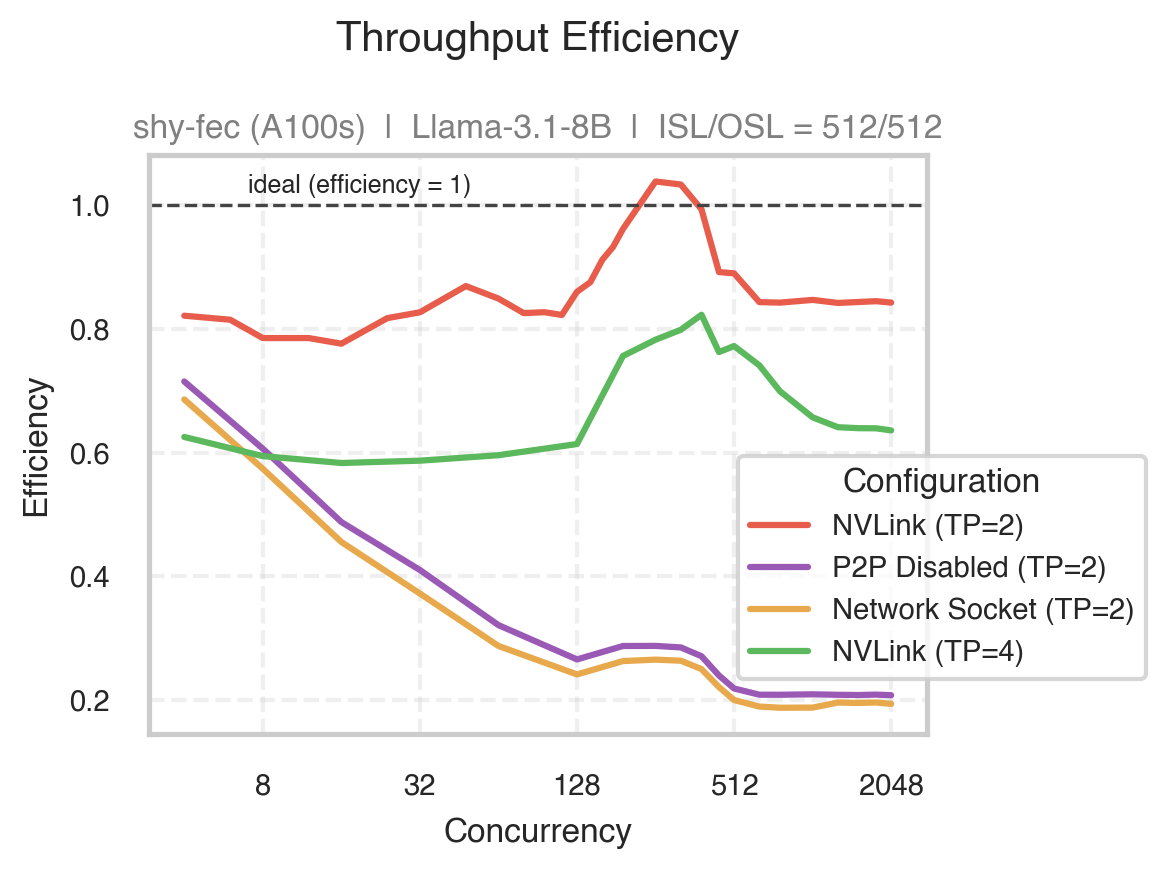

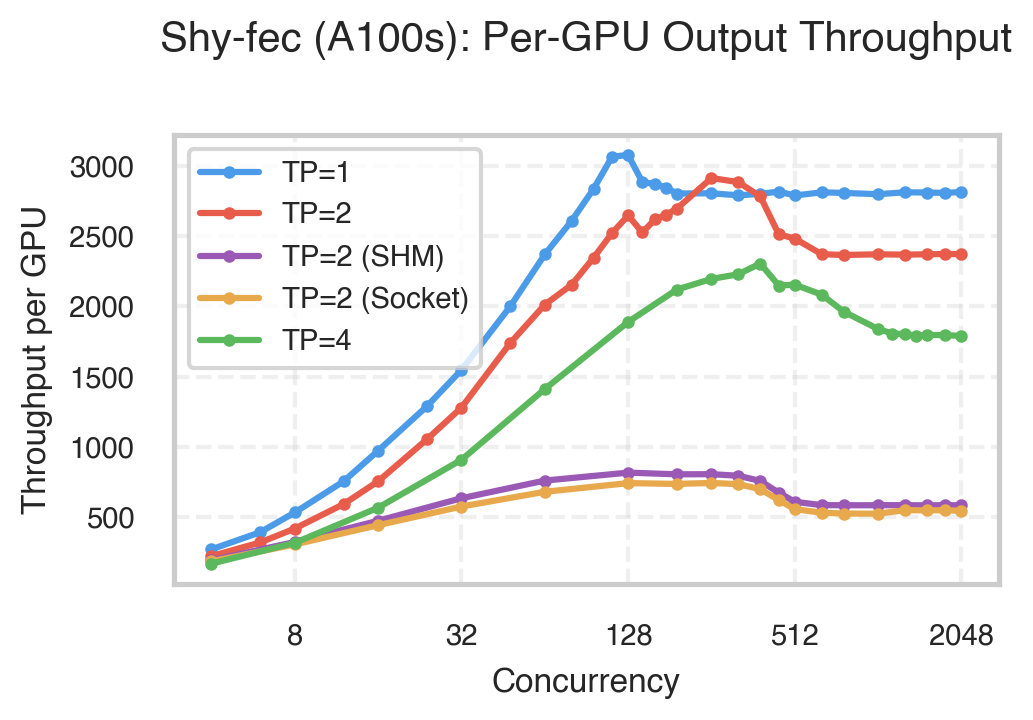

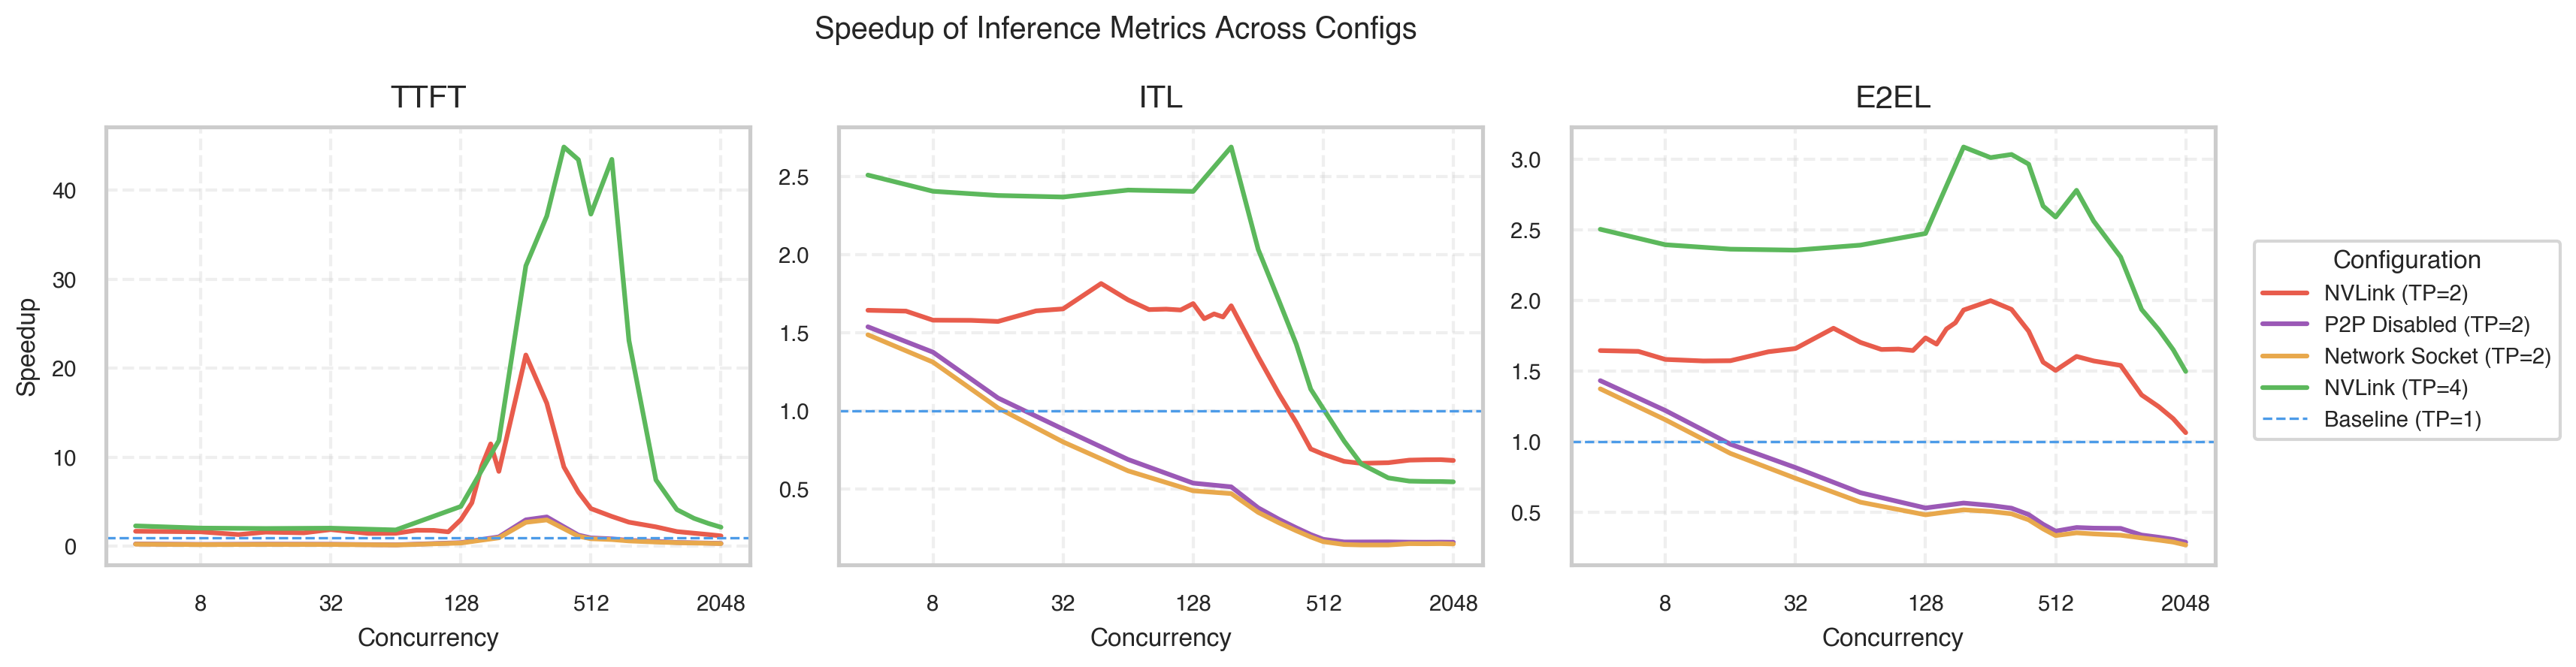

In [264]:
labels = ['mainsweep','p2pdisabled','networkfallback','mainsweep_tp4']
legend_labels = ['NVLink (TP=2)', 'P2P Disabled (TP=2)', 'Network Socket (TP=2)', 'NVLink (TP=4)']

fig_a100_thp_efficiency = plot_throughput_efficiency(
    derived_a100,
    title='Throughput Efficiency',
    labels=labels,
    legend_labels=legend_labels,
    subtitle_info=sub)

fig_a100_thp_normalized = plot_normalized_throughput(
    [tp1_a100_df, tp2_a100_df, tp2_a100_shm_df, tp2_a100_nwfb_df, tp4_a100_df],
    title="Shy-fec (A100s): Per-GPU Output Throughput",
    labels=["TP=1", "TP=2", "TP=2 (SHM)", "TP=2 (Socket)", "TP=4"],
    colors=["#4C9BE8", "#E85C4C","#9B59B6", "#E8A84C", "#5CB85C"],
    subtitle_info=sub,
    paper=True,
    tps=[1,2,2,2,4]
)

fig = plot_speedup_all(
    derived_a100, 
    labels=labels,
    legend_labels=legend_labels,
)

#show_side_by_side(fig_a100_thp_efficiency, fig_a100_thp_normalized)

## V100 Results (funnotch)

### TP Scaling

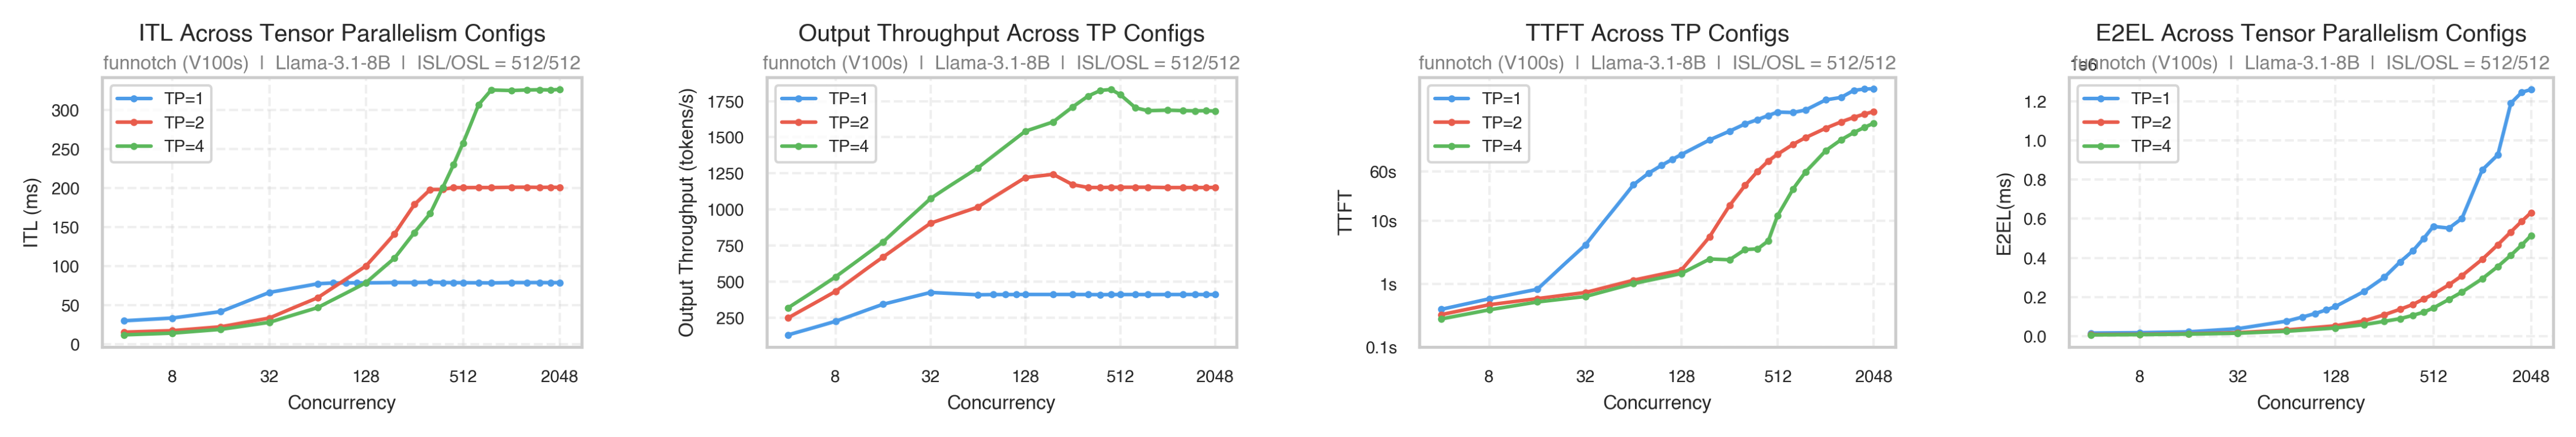

In [265]:
sub = dict(gpu='funnotch (V100s)', model='Llama-3.1-8B', config='ISL/OSL = 512/512')

fig_ttft = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp4_v100_df],
    metric="mean_ttft_ms",
    ylabel="TTFT",
    title="TTFT Across TP Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    log_scale=True,
    subtitle_info=sub
)
fig_itl = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp4_v100_df],
    metric="mean_itl_ms",
    ylabel="ITL (ms)",
    title="ITL Across Tensor Parallelism Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub
)
fig_e2el = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp4_v100_df],
    metric="mean_e2el_ms",
    ylabel="E2EL(ms)",
    title="E2EL Across Tensor Parallelism Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub
)
fig_thp = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp4_v100_df],
    metric="output_throughput",
    ylabel="Output Throughput (tokens/s)",
    title="Output Throughput Across TP Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub
)
show_side_by_side(fig_itl, fig_thp, fig_ttft, fig_e2el)

### Interconnect Comparison
PCIe vs P2P Disabled vs Network Socket

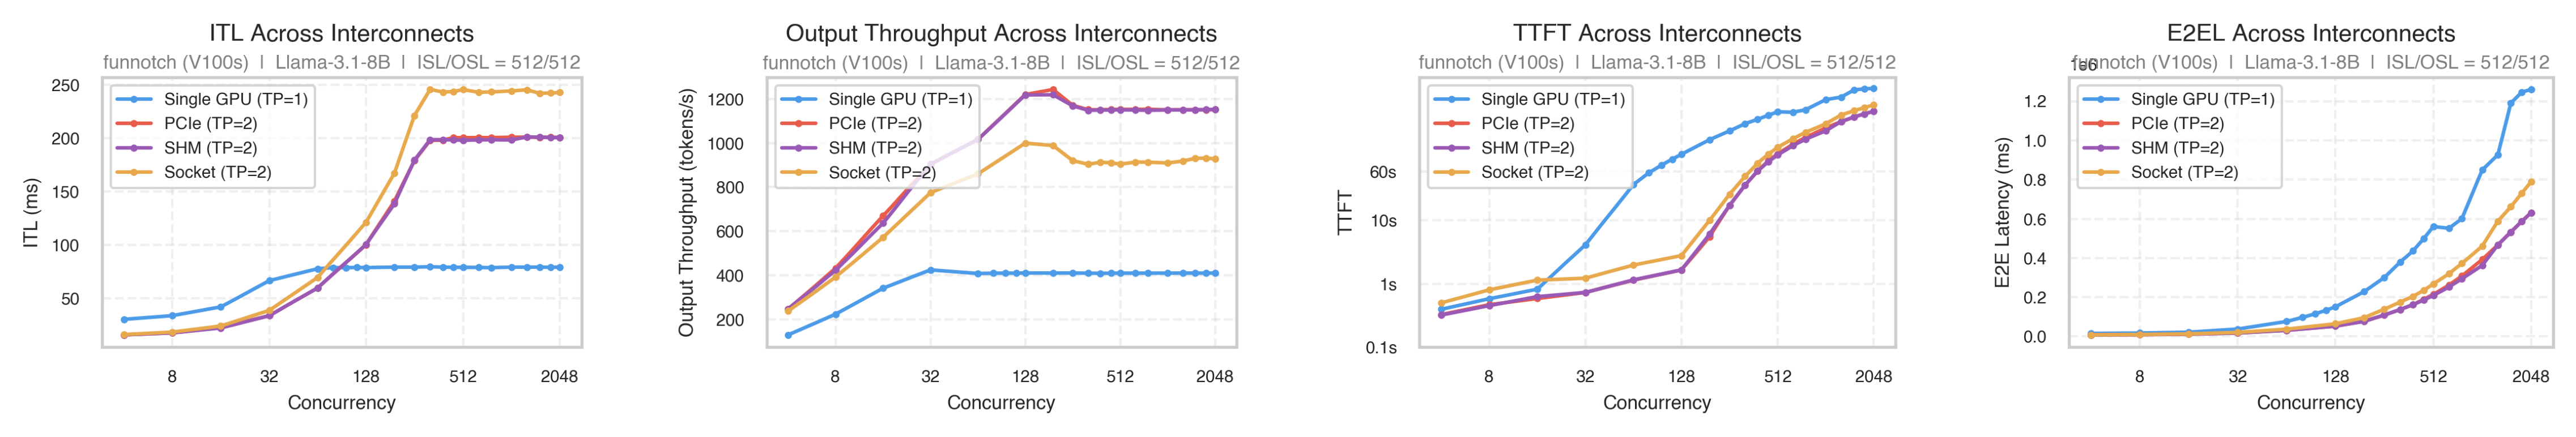

In [266]:

fig_thp = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp2_v100_shm_df, tp2_v100_nwfb_df],
    metric="output_throughput",
    ylabel="Output Throughput (tokens/s)",
    title="Output Throughput Across Interconnects",
    labels=["Single GPU (TP=1)", "PCIe (TP=2)", "SHM (TP=2)", "Socket (TP=2)"],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C"],
    subtitle_info=sub,
)

fig_itl = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp2_v100_shm_df, tp2_v100_nwfb_df],
    metric="mean_itl_ms",
    ylabel="ITL (ms)",
    title="ITL Across Interconnects",
    labels=["Single GPU (TP=1)", "PCIe (TP=2)", "SHM (TP=2)", "Socket (TP=2)"],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C"],
    subtitle_info=sub,
)

fig_e2el = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp2_v100_shm_df, tp2_v100_nwfb_df],
    metric="mean_e2el_ms",
    ylabel="E2E Latency (ms)",
    title="E2EL Across Interconnects",
    labels=["Single GPU (TP=1)", "PCIe (TP=2)", "SHM (TP=2)", "Socket (TP=2)"],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C"],
    subtitle_info=sub,
)

fig_ttft = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp2_v100_shm_df, tp2_v100_nwfb_df],
    metric="mean_ttft_ms",
    ylabel="TTFT",
    title="TTFT Across Interconnects",
    labels=["Single GPU (TP=1)", "PCIe (TP=2)", "SHM (TP=2)", "Socket (TP=2)"],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C"],
    log_scale=True,
    subtitle_info=sub,
)
show_side_by_side(fig_itl, fig_thp, fig_ttft, fig_e2el)

### Scaling Efficiency

In [267]:
for label, grp in derived_v100.groupby('label'):
    print(f"\n── {label} ──")
    print(grp[['max_concurrency', 'relative_itl_slowdown',
                'degradation', 'observed_allreduce_latency_ms',
                'throughput_efficiency', 'observed_comm_overhead_ms']].to_string(index=False))
    


── mainsweep ──
 max_concurrency  relative_itl_slowdown  degradation  observed_allreduce_latency_ms  throughput_efficiency  observed_comm_overhead_ms
               4               0.519476   -48.052449                      -0.225582               0.948551                 -14.437219
               8               0.522894   -47.710630                      -0.249835               0.965999                 -15.989438
              16               0.537520   -46.248004                      -0.301374               0.979798                 -19.287963
              32               0.504328   -49.567196                      -0.514003               1.064854                 -32.896165
              64               0.769870   -23.012963                      -0.278521               1.245560                 -17.825327
             128               1.274590    27.459039                       0.336993               1.487549                  21.567579
             192               1.785358    78

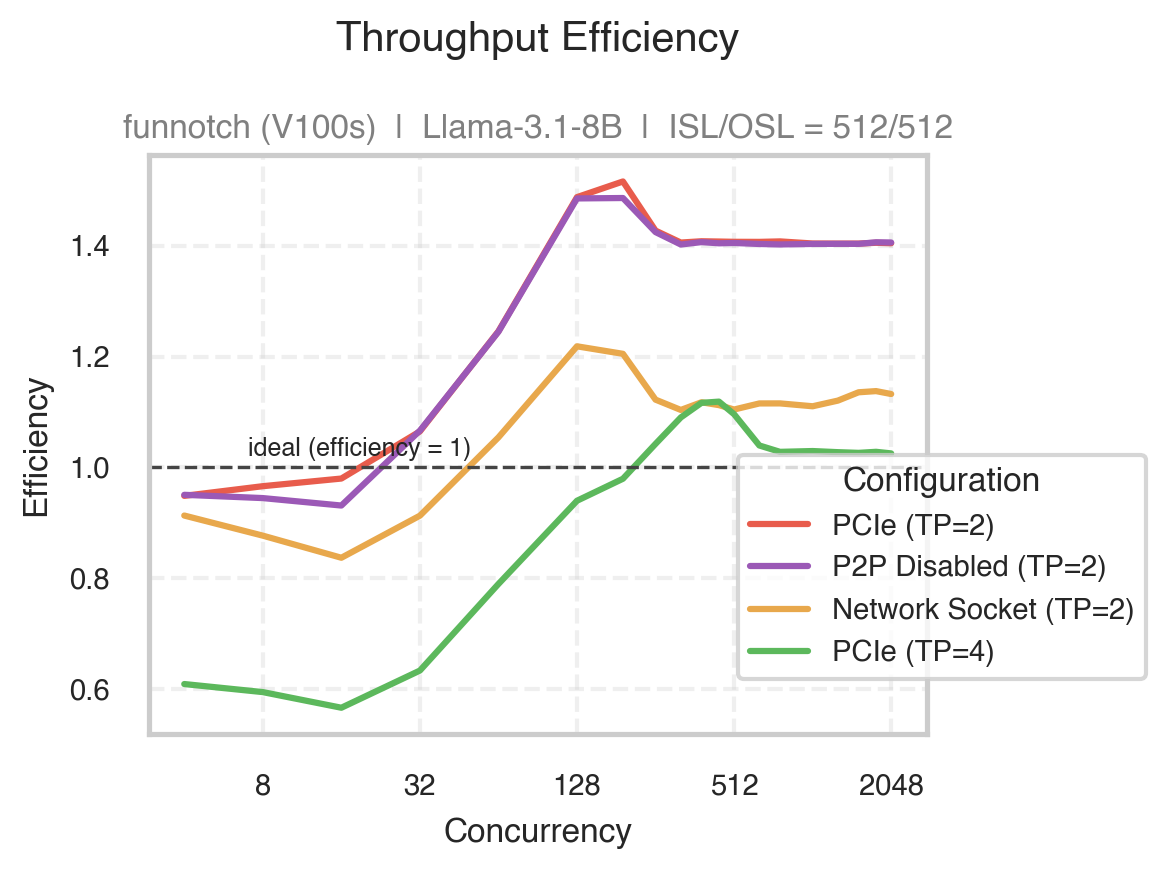

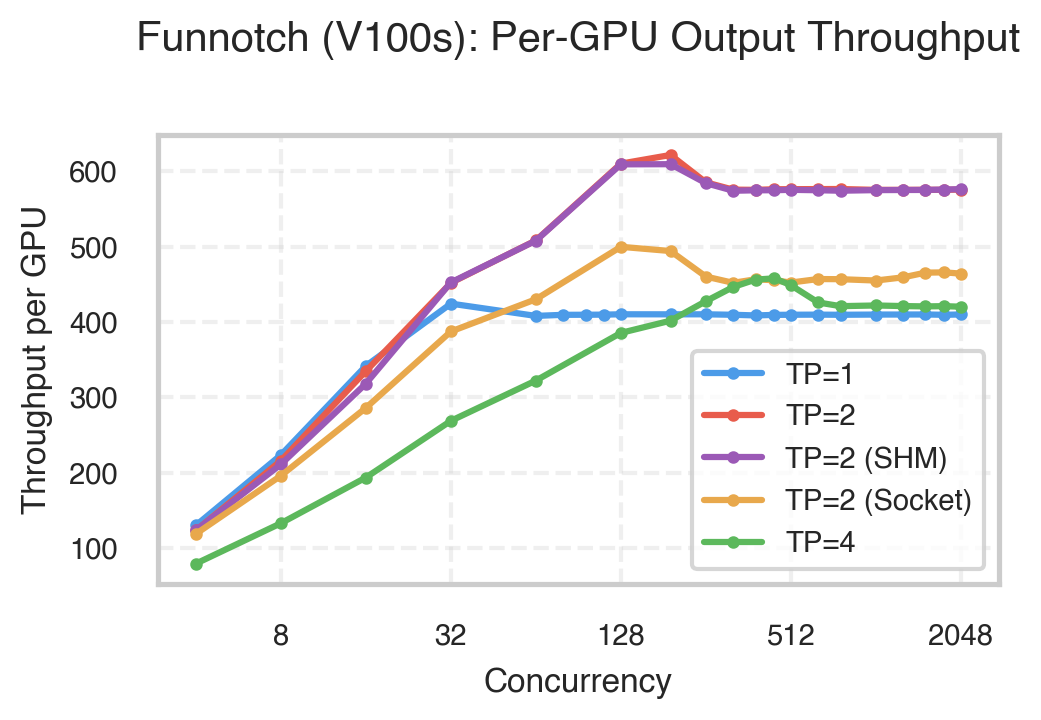

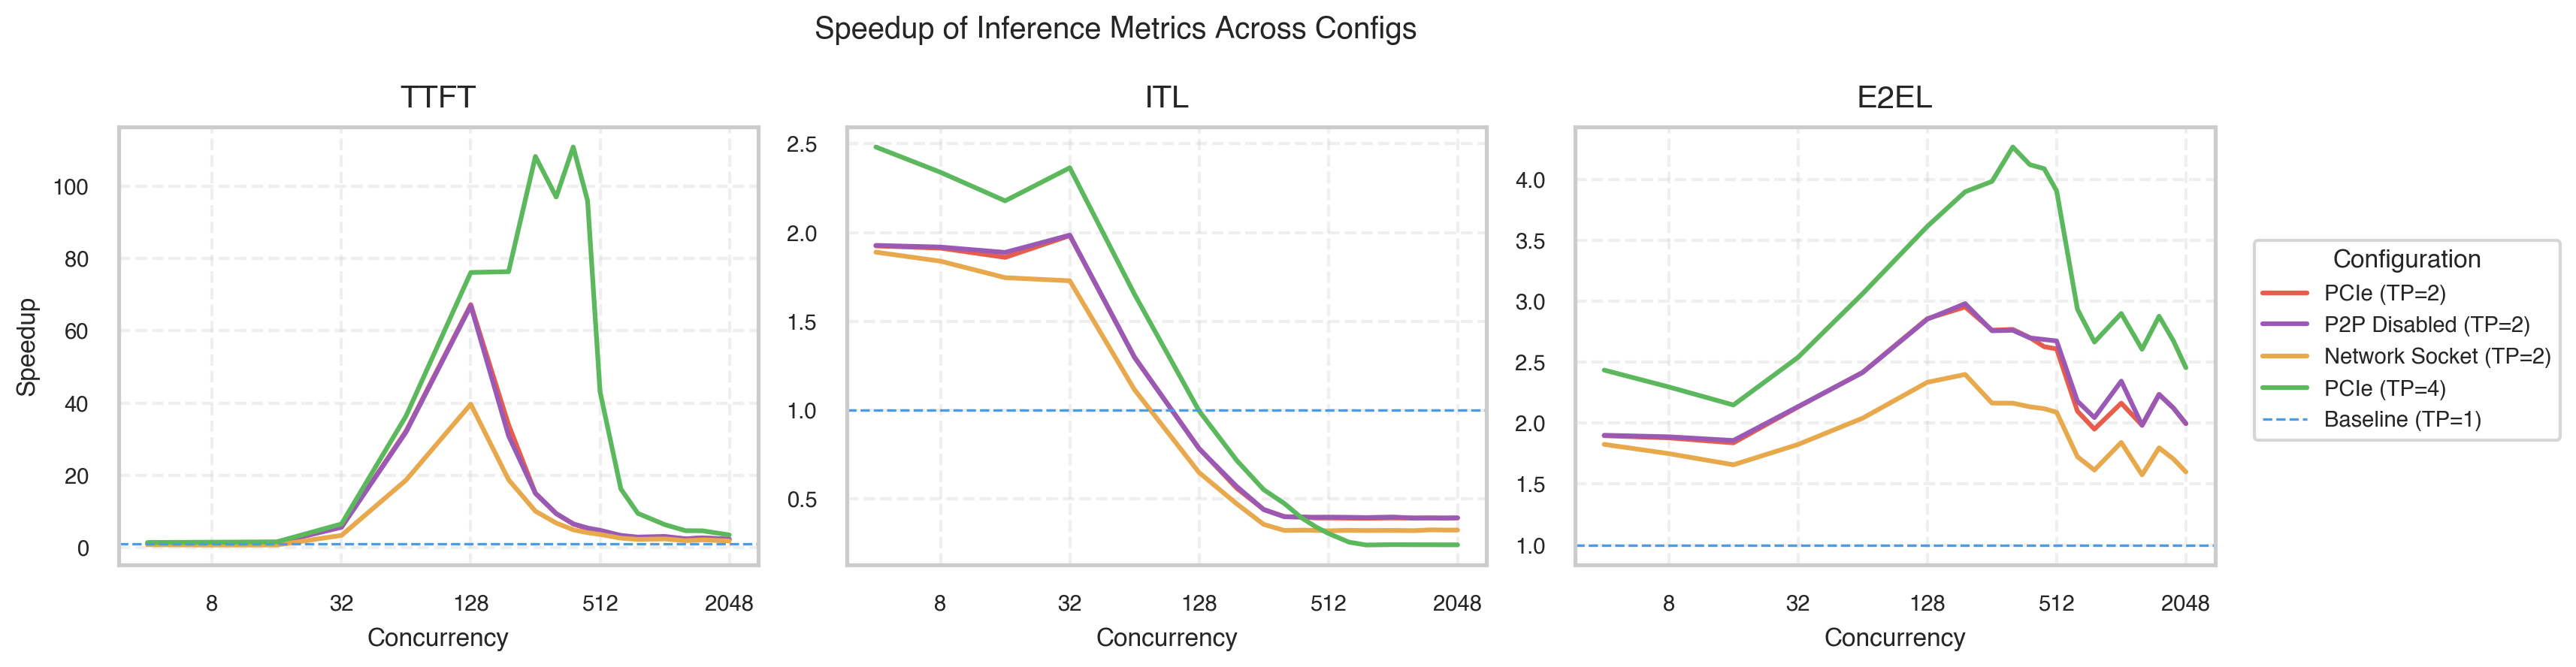

In [268]:
labels = ['mainsweep','p2pdisabled','networkfallback','mainsweep_tp4']
legend_labels = ['PCIe (TP=2)', 'P2P Disabled (TP=2)', 'Network Socket (TP=2)', 'PCIe (TP=4)']

fig_v100_thp_efficiency = plot_throughput_efficiency(
    derived_v100,
    title='Throughput Efficiency',
    labels=labels,
    legend_labels=legend_labels,
    subtitle_info=sub)
fig_v100_thp_normalized = plot_normalized_throughput(
    [tp1_v100_df, tp2_v100_df, tp2_v100_shm_df, tp2_v100_nwfb_df, tp4_v100_df],
    title="Funnotch (V100s): Per-GPU Output Throughput",
    labels=["TP=1", "TP=2", "TP=2 (SHM)", "TP=2 (Socket)", "TP=4"],
    colors=["#4C9BE8", "#E85C4C","#9B59B6", "#E8A84C", "#5CB85C"],
    subtitle_info=sub,
    paper=True,
    tps=[1,2,2,2,4]
)

fig = plot_speedup_all(
    derived_v100, 
    labels=labels,
    legend_labels=legend_labels,
)
#show_side_by_side(fig_v100_thp_efficiency, fig_v100_thp_normalized)

## Comparison Between shy-fec & funnotch

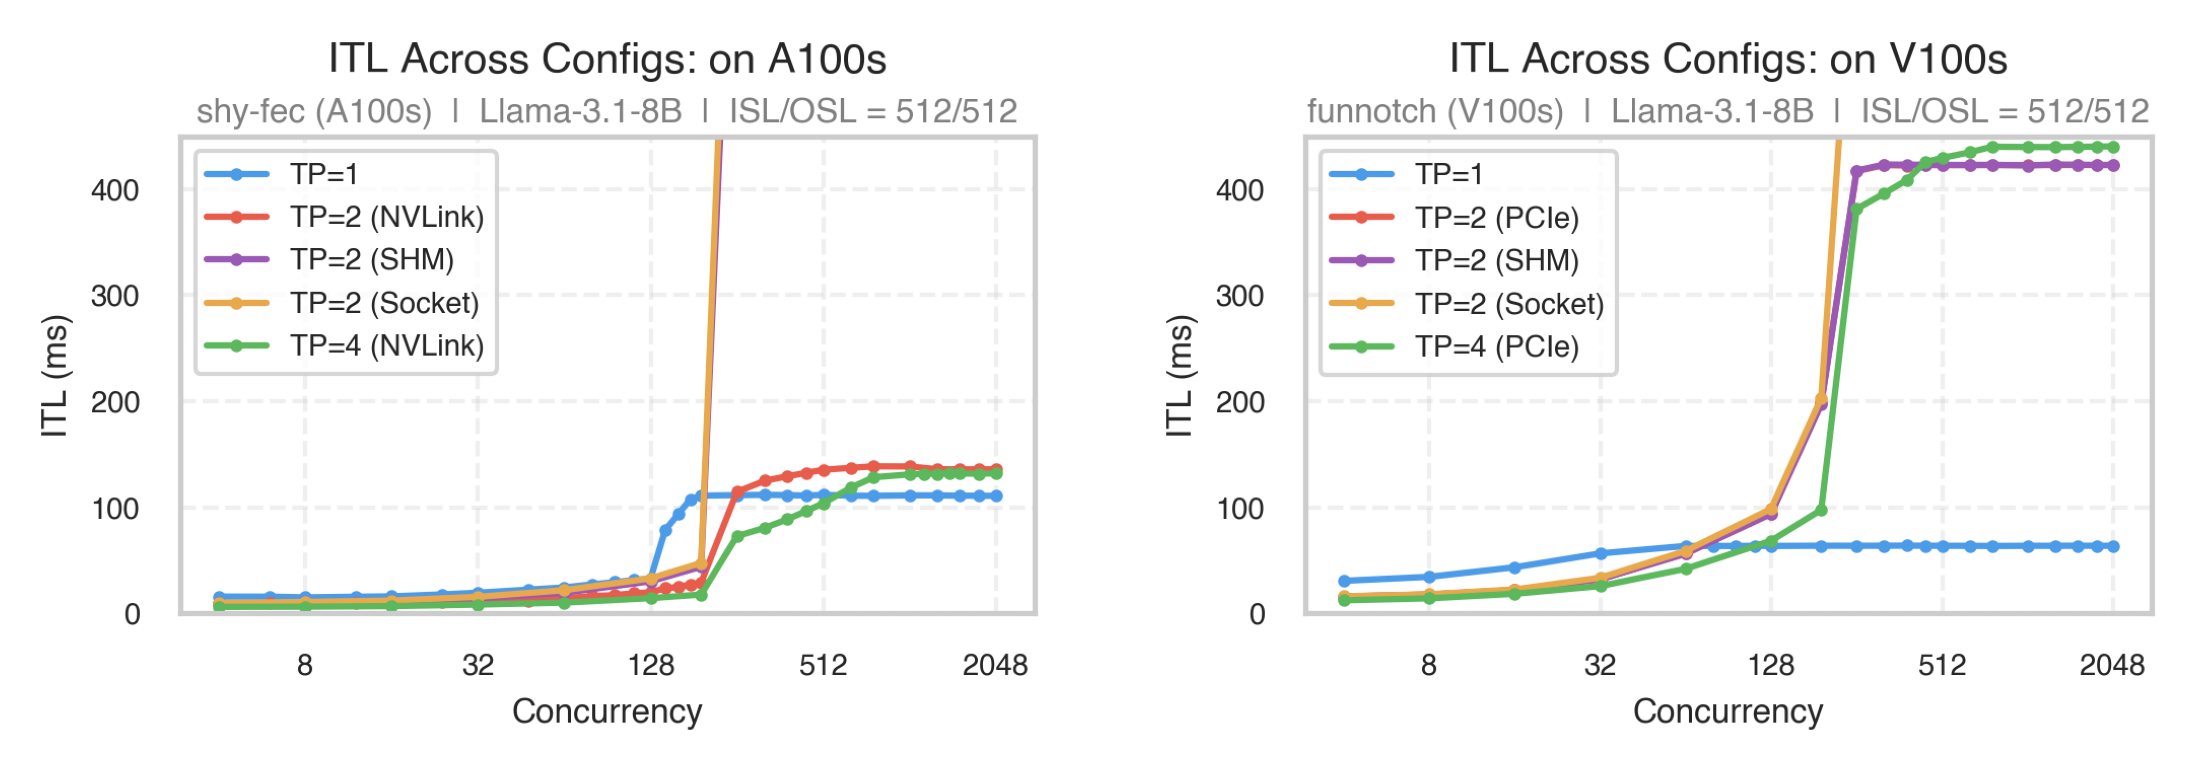

In [302]:
sub_funnotch = dict(gpu='funnotch (V100s)', model='Llama-3.1-8B', config='ISL/OSL = 512/512')
sub_shyfec = dict(gpu='shy-fec (A100s)', model='Llama-3.1-8B', config='ISL/OSL = 512/512')
fig_a100_itl = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp2_a100_shm_df, tp2_a100_nwfb_df, tp4_a100_df],
    metric="p90_itl_ms",
    ylabel="ITL (ms)",
    title="ITL Across Configs: on A100s",
    y_lim=[0, 450],
    labels=["TP=1", "TP=2 (NVLink)", "TP=2 (SHM)", "TP=2 (Socket)", "TP=4 (NVLink)"],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C", "#5CB85C"],
    subtitle_info=sub_shyfec,
)
fig_v100_itl = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp2_v100_shm_df, tp2_v100_nwfb_df, tp4_v100_df],
    metric="p90_itl_ms",
    ylabel="ITL (ms)",
    title="ITL Across Configs: on V100s",
    y_lim=[0, 450],
    labels=["TP=1", "TP=2 (PCIe)", "TP=2 (SHM)", "TP=2 (Socket)", "TP=4 (PCIe)"],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C", "#5CB85C"],
    subtitle_info=sub_funnotch
)
show_side_by_side(fig_a100_itl, fig_v100_itl)

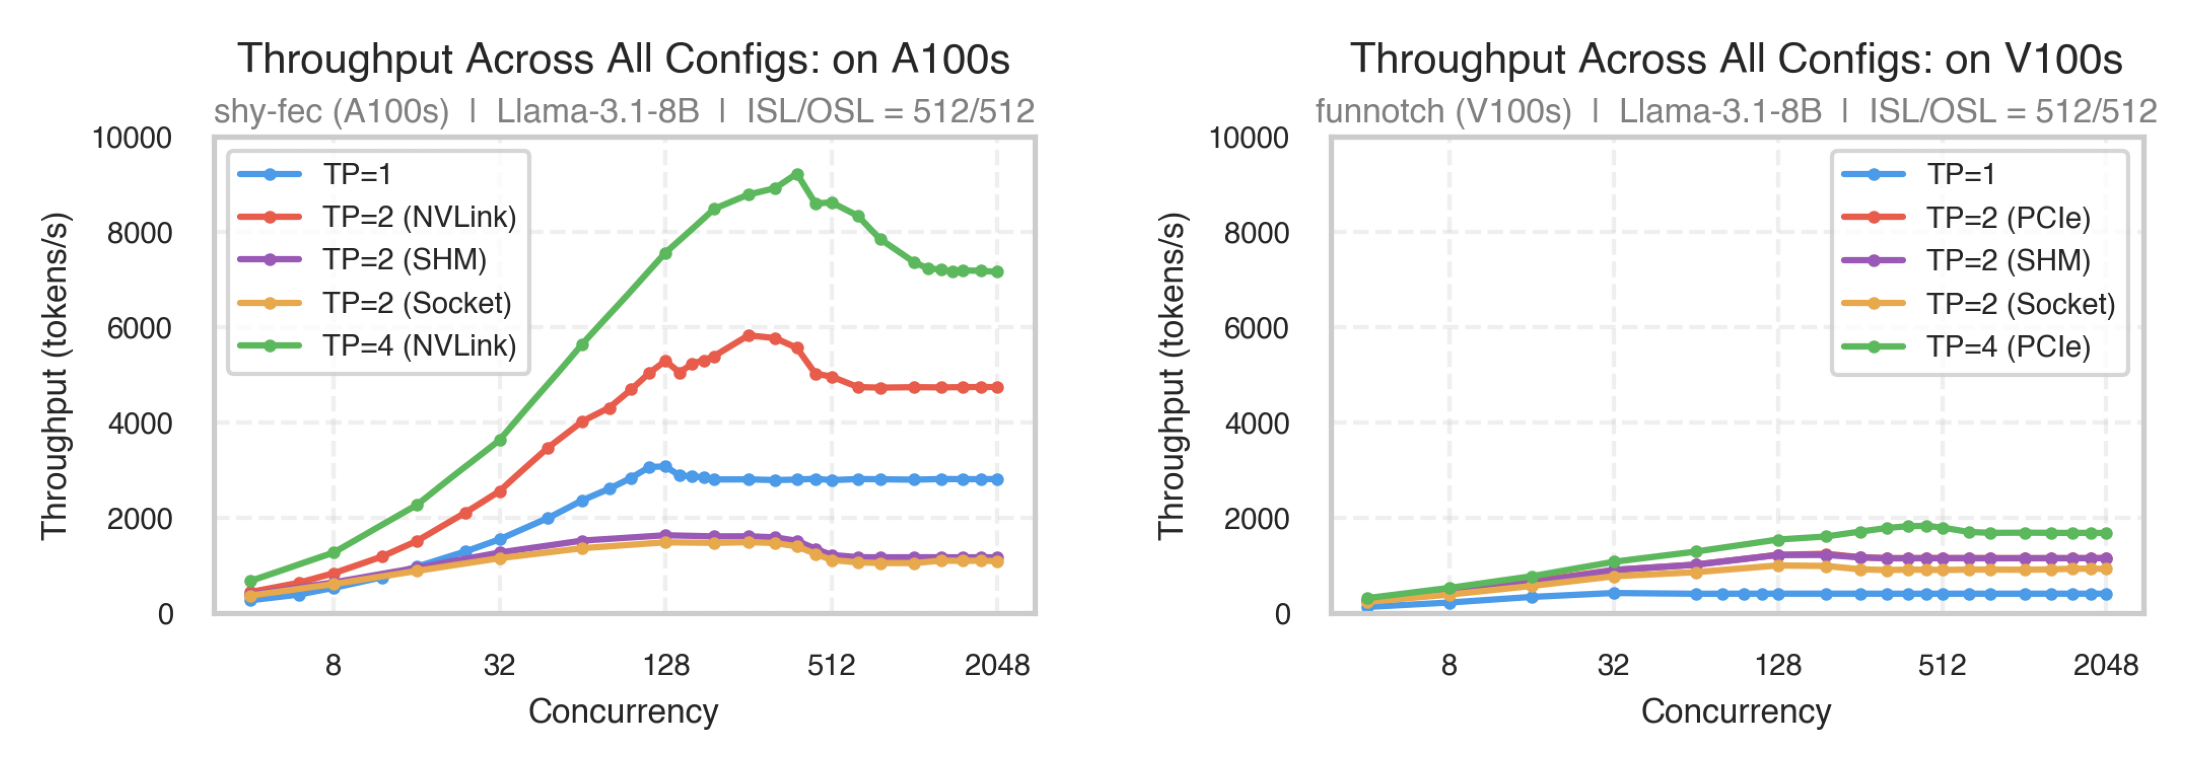

In [270]:
fig_a100_thp = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp2_a100_shm_df, tp2_a100_nwfb_df, tp4_a100_df],
    metric="output_throughput",
    ylabel="Throughput (tokens/s)",
    title="Throughput Across All Configs: on A100s",
    y_lim=[0, 10000],
    labels=["TP=1", "TP=2 (NVLink)", "TP=2 (SHM)", "TP=2 (Socket)", "TP=4 (NVLink)"],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C", "#5CB85C"],
    subtitle_info=sub_shyfec,
)
fig_v100_thp = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp2_v100_shm_df, tp2_v100_nwfb_df, tp4_v100_df],
    metric="output_throughput",
    ylabel="Throughput (tokens/s)",
    title="Throughput Across All Configs: on V100s",
    y_lim=[0, 10000],
    labels=["TP=1", "TP=2 (PCIe)", "TP=2 (SHM)", "TP=2 (Socket)", "TP=4 (PCIe)"],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C", "#5CB85C"],
    subtitle_info=sub_funnotch,
)
show_side_by_side(fig_a100_thp, fig_v100_thp)

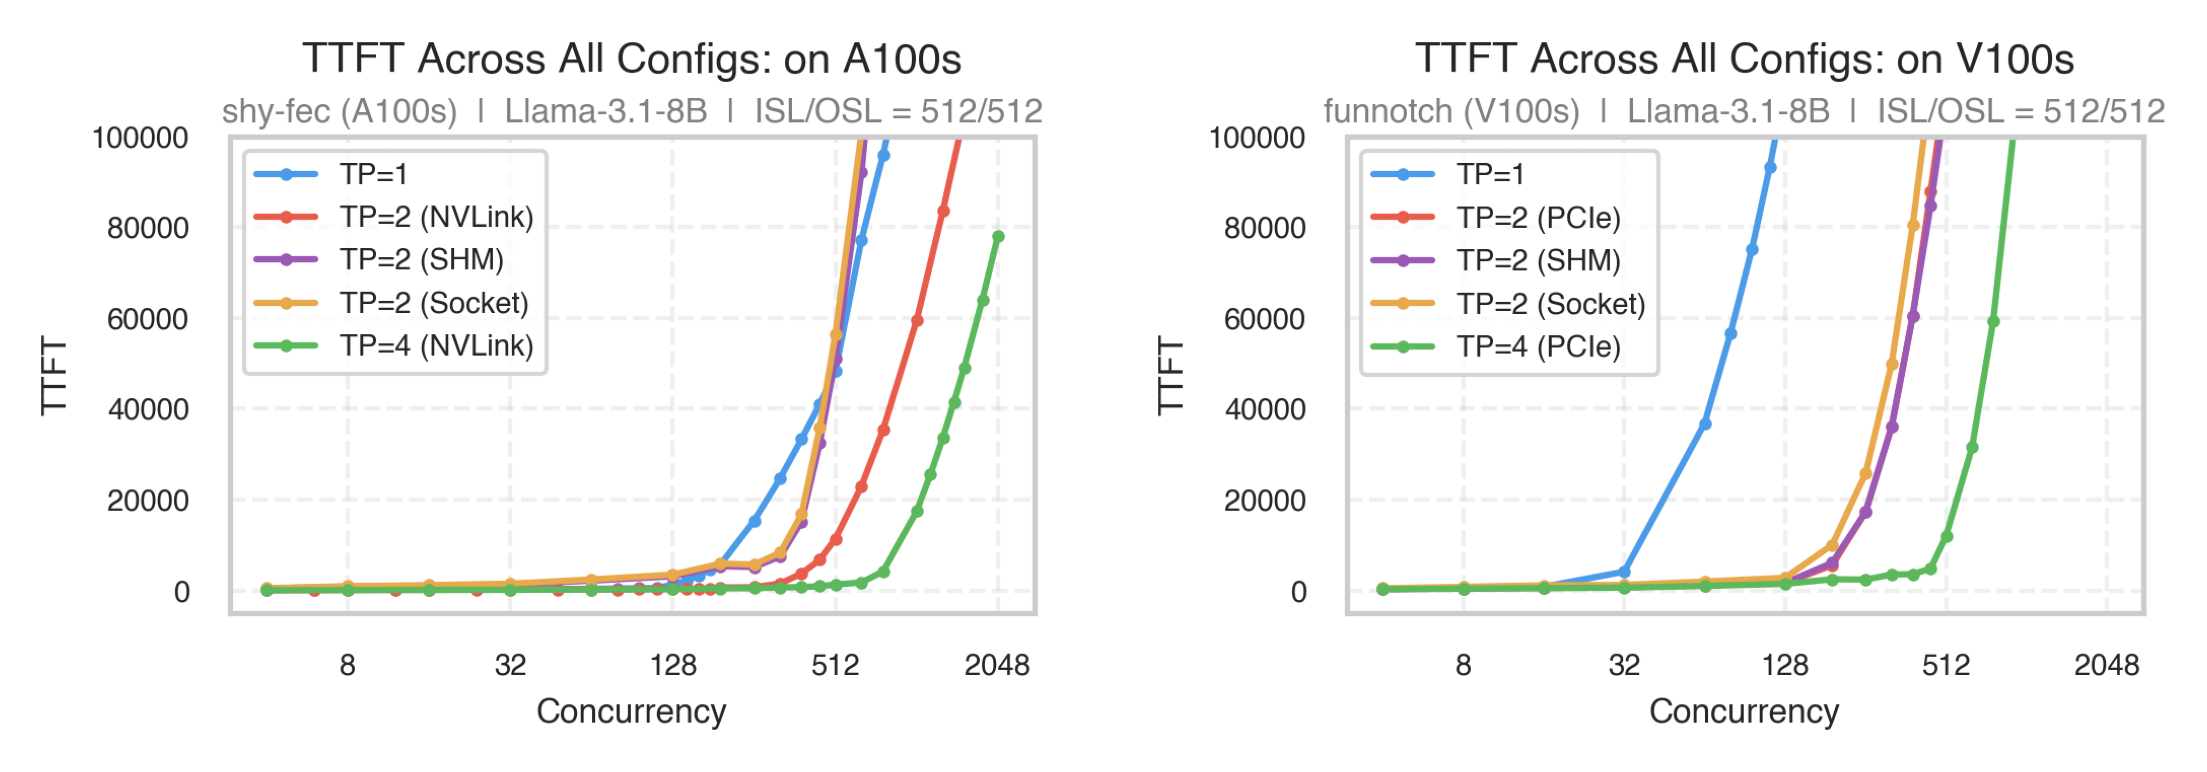

In [293]:
fig_a100_ttft = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp2_a100_shm_df, tp2_a100_nwfb_df, tp4_a100_df],
    metric="mean_ttft_ms",
    ylabel="TTFT",
    title="TTFT Across All Configs: on A100s",
    labels=["TP=1", "TP=2 (NVLink)", "TP=2 (SHM)", "TP=2 (Socket)", "TP=4 (NVLink)"],
    y_lim=[-5000, 100000],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C", "#5CB85C"],
    subtitle_info=sub_shyfec,
)
fig_v100_ttft = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp2_v100_shm_df, tp2_v100_nwfb_df, tp4_v100_df],
    metric="mean_ttft_ms",
    ylabel="TTFT",
    title="TTFT Across All Configs: on V100s",
    labels=["TP=1", "TP=2 (PCIe)", "TP=2 (SHM)", "TP=2 (Socket)", "TP=4 (PCIe)"],
    y_lim=[-5000, 100000],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C", "#5CB85C"],
    subtitle_info=sub_funnotch,
)
show_side_by_side(fig_a100_ttft, fig_v100_ttft)

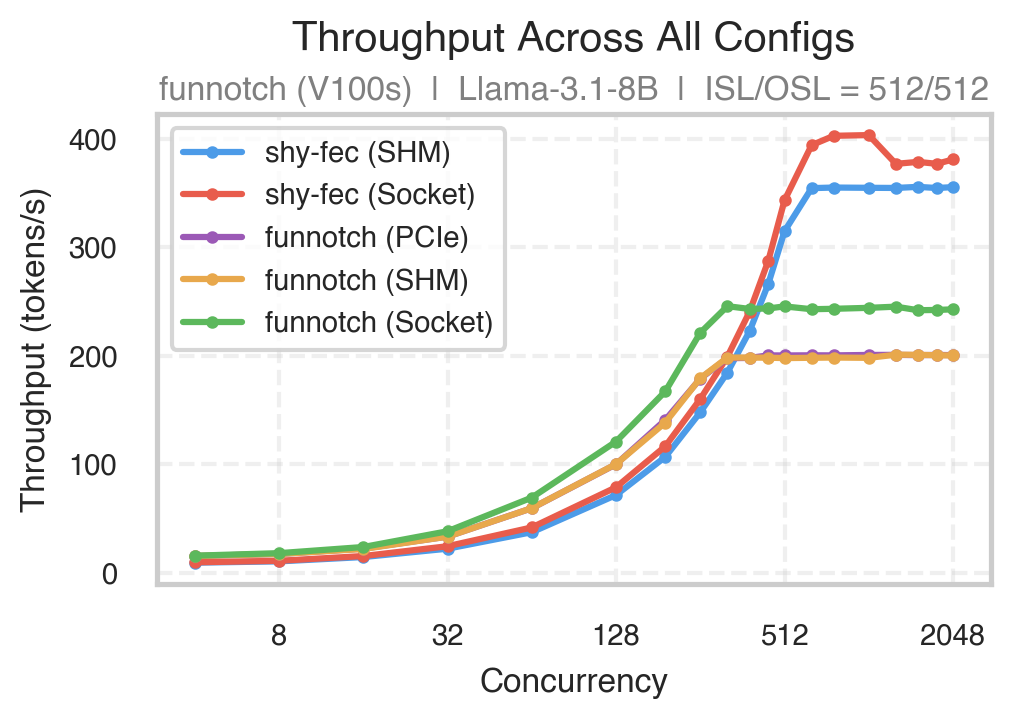

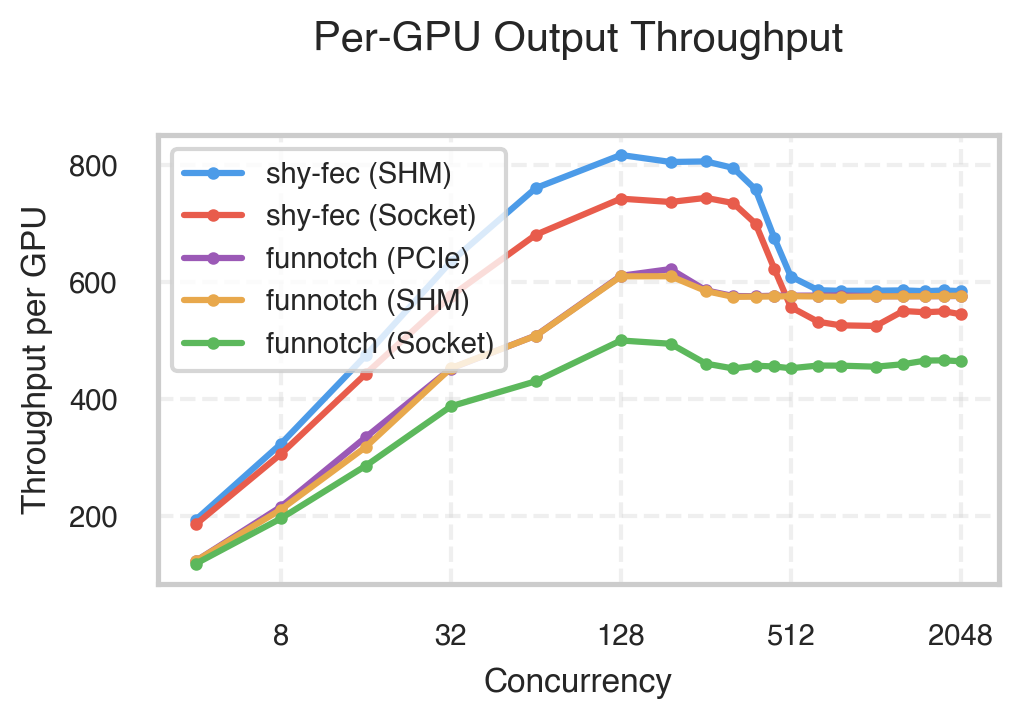

In [301]:
fig_thp = plot_metric_vs_concurrency(
    [tp2_a100_shm_df, tp2_a100_nwfb_df, tp2_v100_df, tp2_v100_shm_df, tp2_v100_nwfb_df ],
    metric="mean_tpot_ms",
    ylabel="Throughput (tokens/s)",
    title="Throughput Across All Configs",
    labels=["shy-fec (SHM)", "shy-fec (Socket)", "funnotch (PCIe)", "funnotch (SHM)", "funnotch (Socket)"],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C", "#5CB85C"],
    subtitle_info=sub_funnotch,
)
fig_v100_thp_normalized = plot_normalized_throughput(
    [tp2_a100_shm_df, tp2_a100_nwfb_df, tp2_v100_df, tp2_v100_shm_df, tp2_v100_nwfb_df ],
    title="Per-GPU Output Throughput",
    labels=["shy-fec (SHM)", "shy-fec (Socket)", "funnotch (PCIe)", "funnotch (SHM)", "funnotch (Socket)"],
    colors=["#4C9BE8", "#E85C4C","#9B59B6", "#E8A84C", "#5CB85C"],
    subtitle_info=sub,
    paper=True,
    tps=[2,2,2,2,2]
)

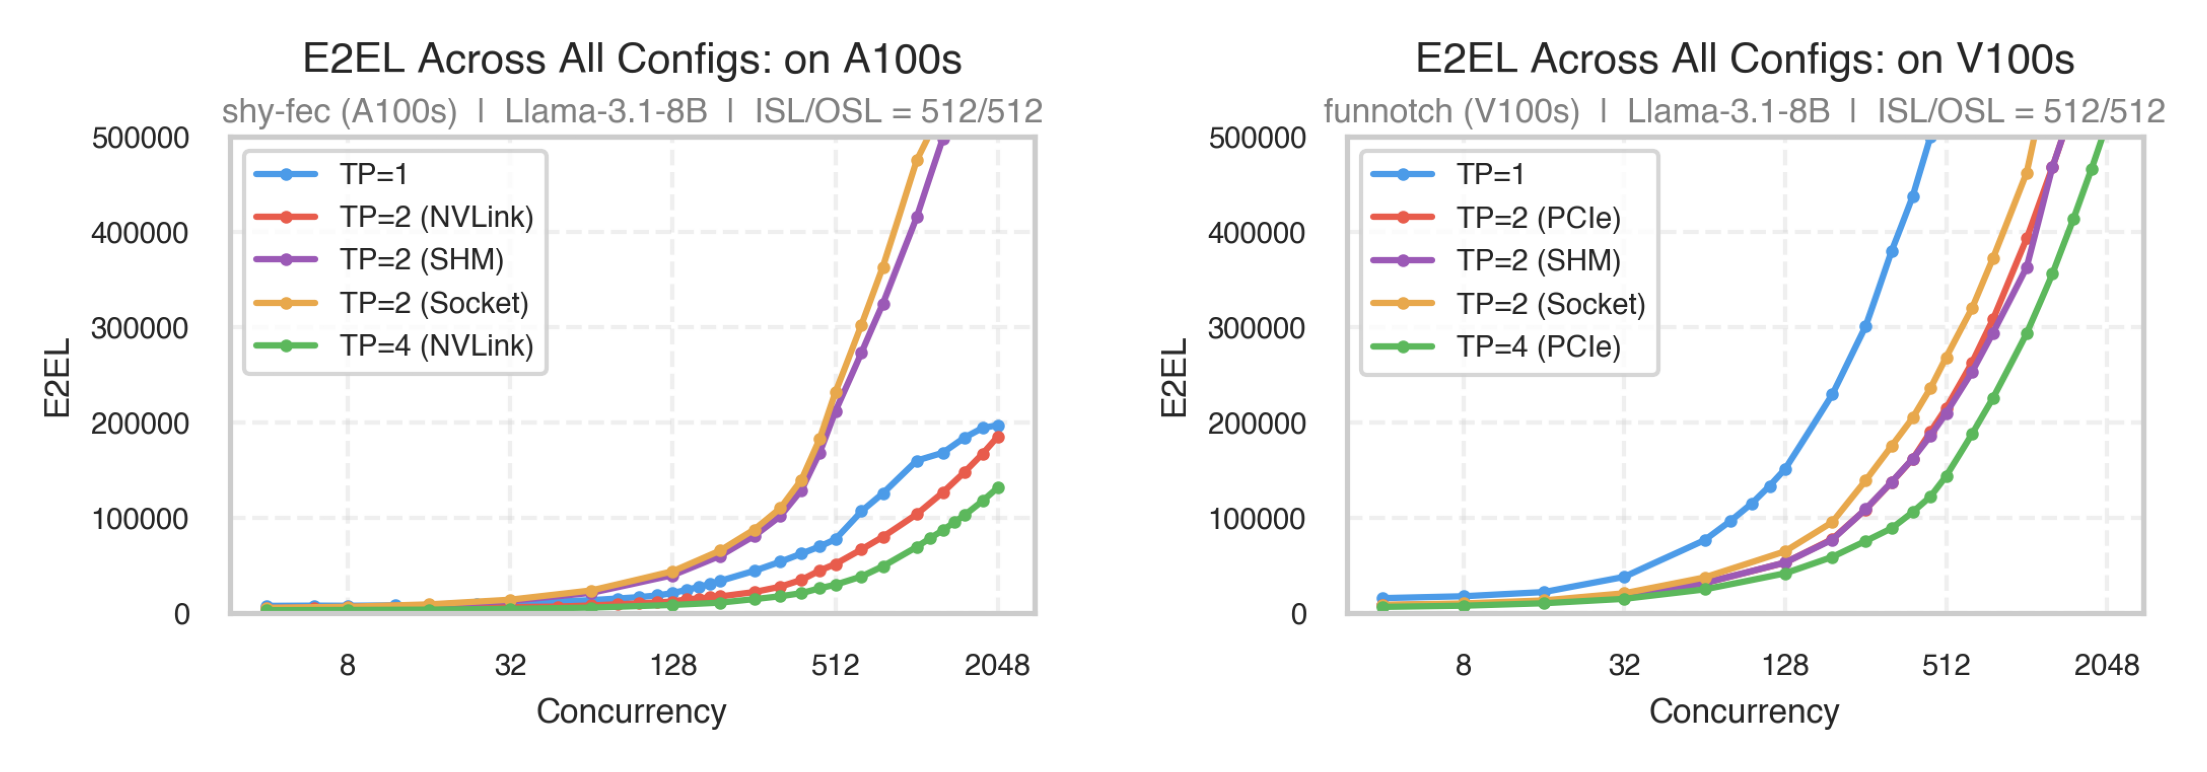

In [290]:
fig_a100_ttft = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp2_a100_shm_df, tp2_a100_nwfb_df, tp4_a100_df],
    metric="mean_e2el_ms",
    ylabel="E2EL",
    title="E2EL Across All Configs: on A100s",
    y_lim=[-100, 500000],
    labels=["TP=1", "TP=2 (NVLink)", "TP=2 (SHM)", "TP=2 (Socket)", "TP=4 (NVLink)"],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C", "#5CB85C"],
    subtitle_info=sub_shyfec,
)
fig_v100_ttft = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp2_v100_shm_df, tp2_v100_nwfb_df, tp4_v100_df],
    metric="mean_e2el_ms",
    ylabel="E2EL",
    title="E2EL Across All Configs: on V100s",
    y_lim=[-100, 500000],
    labels=["TP=1", "TP=2 (PCIe)", "TP=2 (SHM)", "TP=2 (Socket)", "TP=4 (PCIe)"],
    colors=["#4C9BE8", "#E85C4C", "#9B59B6", "#E8A84C", "#5CB85C"],
    subtitle_info=sub_funnotch,
)
show_side_by_side(fig_a100_ttft, fig_v100_ttft)

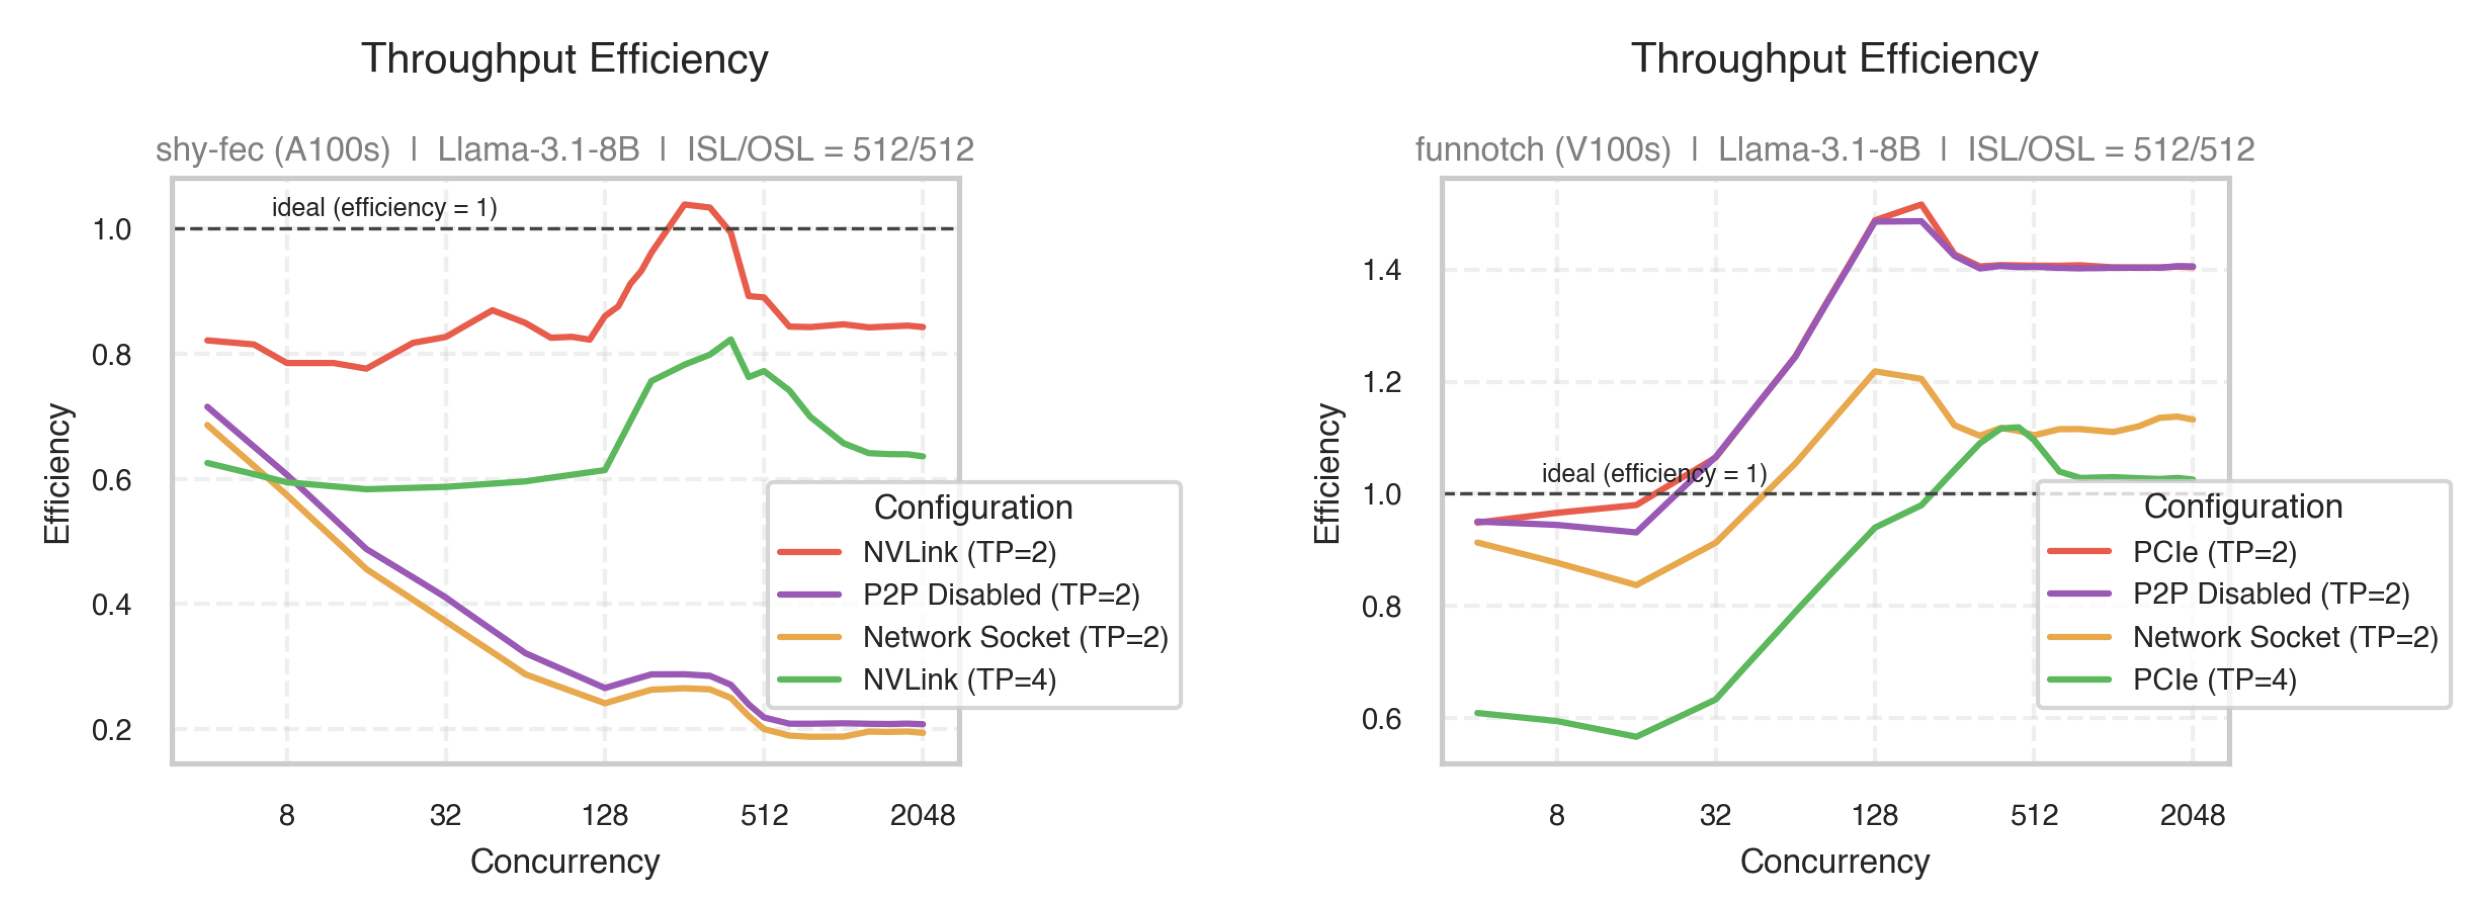

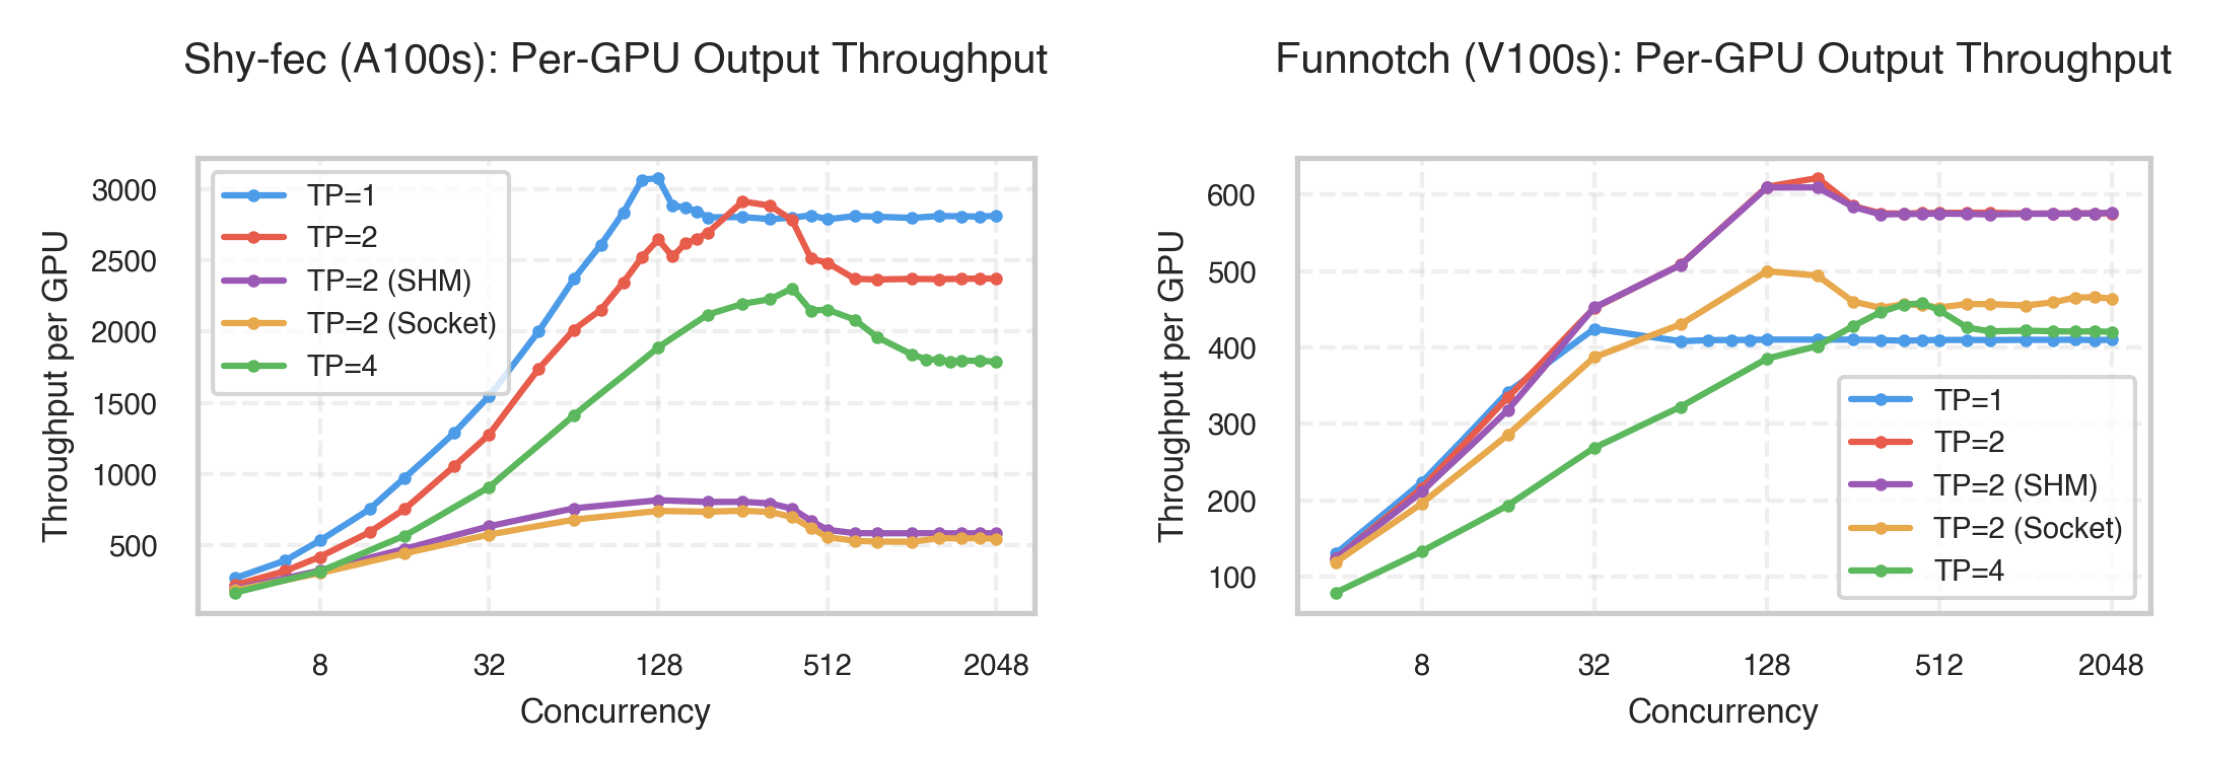

In [272]:
show_side_by_side(fig_a100_thp_efficiency, fig_v100_thp_efficiency)
show_side_by_side(fig_a100_thp_normalized, fig_v100_thp_normalized)


## Service Level Objectives (SLOs) 


In [280]:
def extract_optimal_point(df, config_name, gpu_type, tp, itl_slo, ttft_slo,
                          itl_col='p90_itl_ms', ttft_col='p90_ttft_ms'):
    mask = (df[itl_col] <= itl_slo) & (df[ttft_col] <= ttft_slo)
    valid = df[mask]
    if valid.empty:
        return {
            "config": config_name,
            "gpu": gpu_type,
            "tp": tp,
            "capacity": 0,
            "throughput": 0,
            "p90_ttft": None,
            "p90_itl": None,
            "status": "SLO not met"
        }
    row = valid.loc[valid['output_throughput'].idxmax()]
    
    return {
        "config": config_name,
        "gpu": gpu_type,
        "tp": tp,
        "capacity": row["max_concurrency"],
        "throughput": row["output_throughput"],
        "p90_ttft": row["p90_ttft_ms"],
        "p90_itl": row["p90_itl_ms"],
        "ttft_headroom": ttft_slo - row["p90_ttft_ms"],
        "itl_headroom": itl_slo - row["p90_itl_ms"],
        "status": "OK"
    }


### P75, P90, and P99 of ITLs


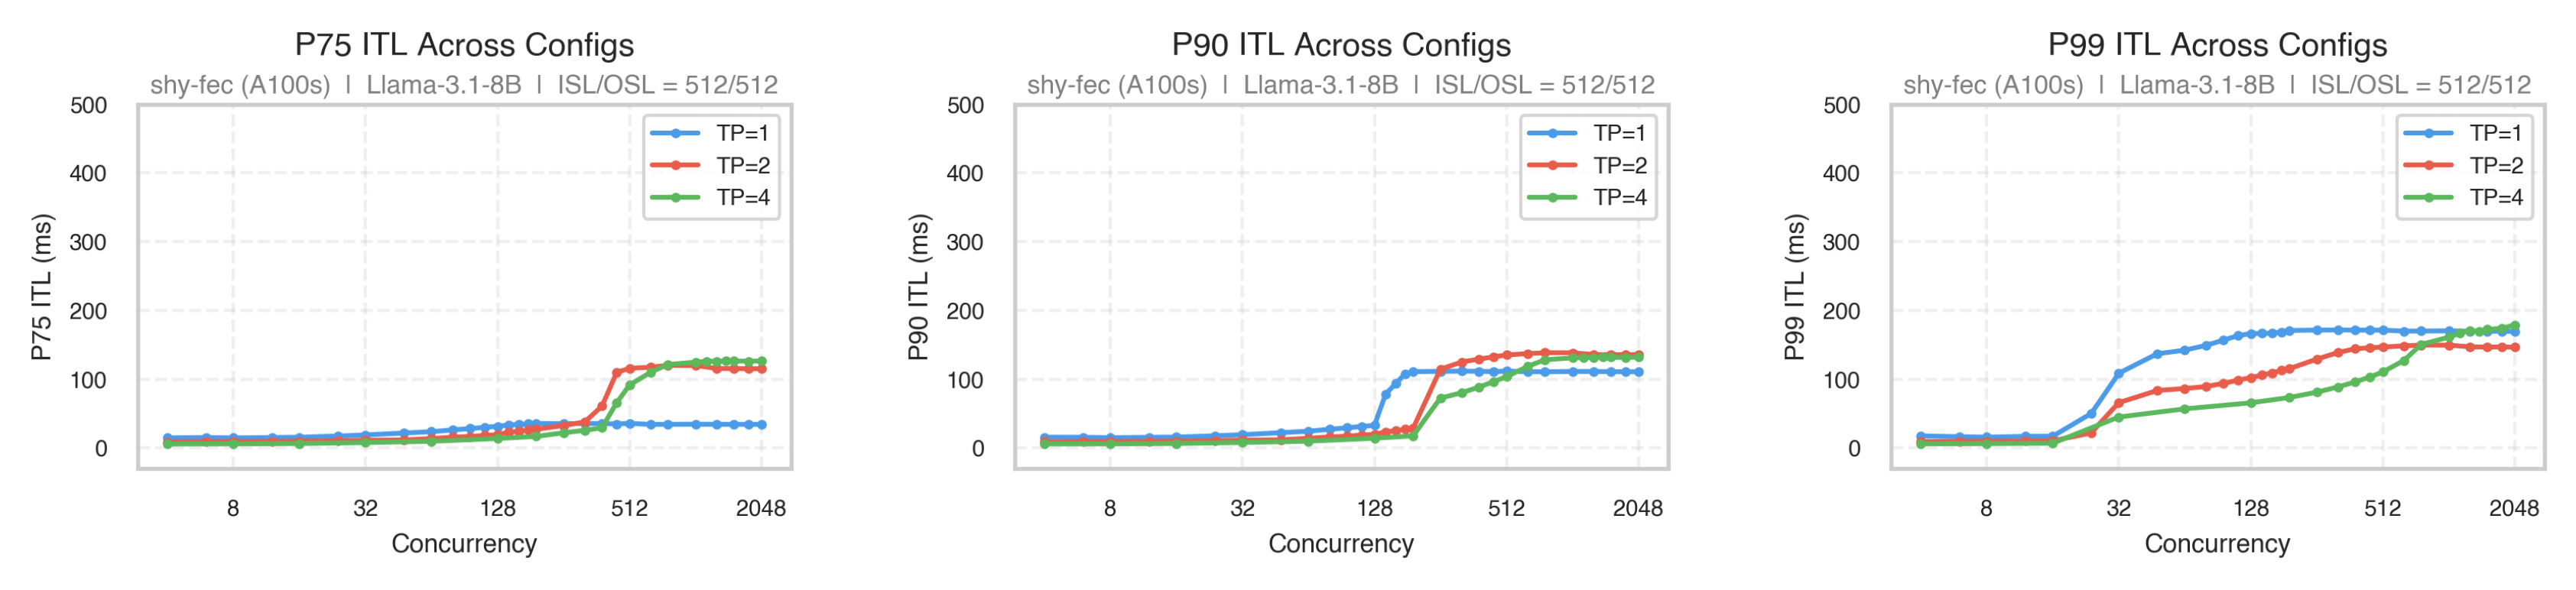

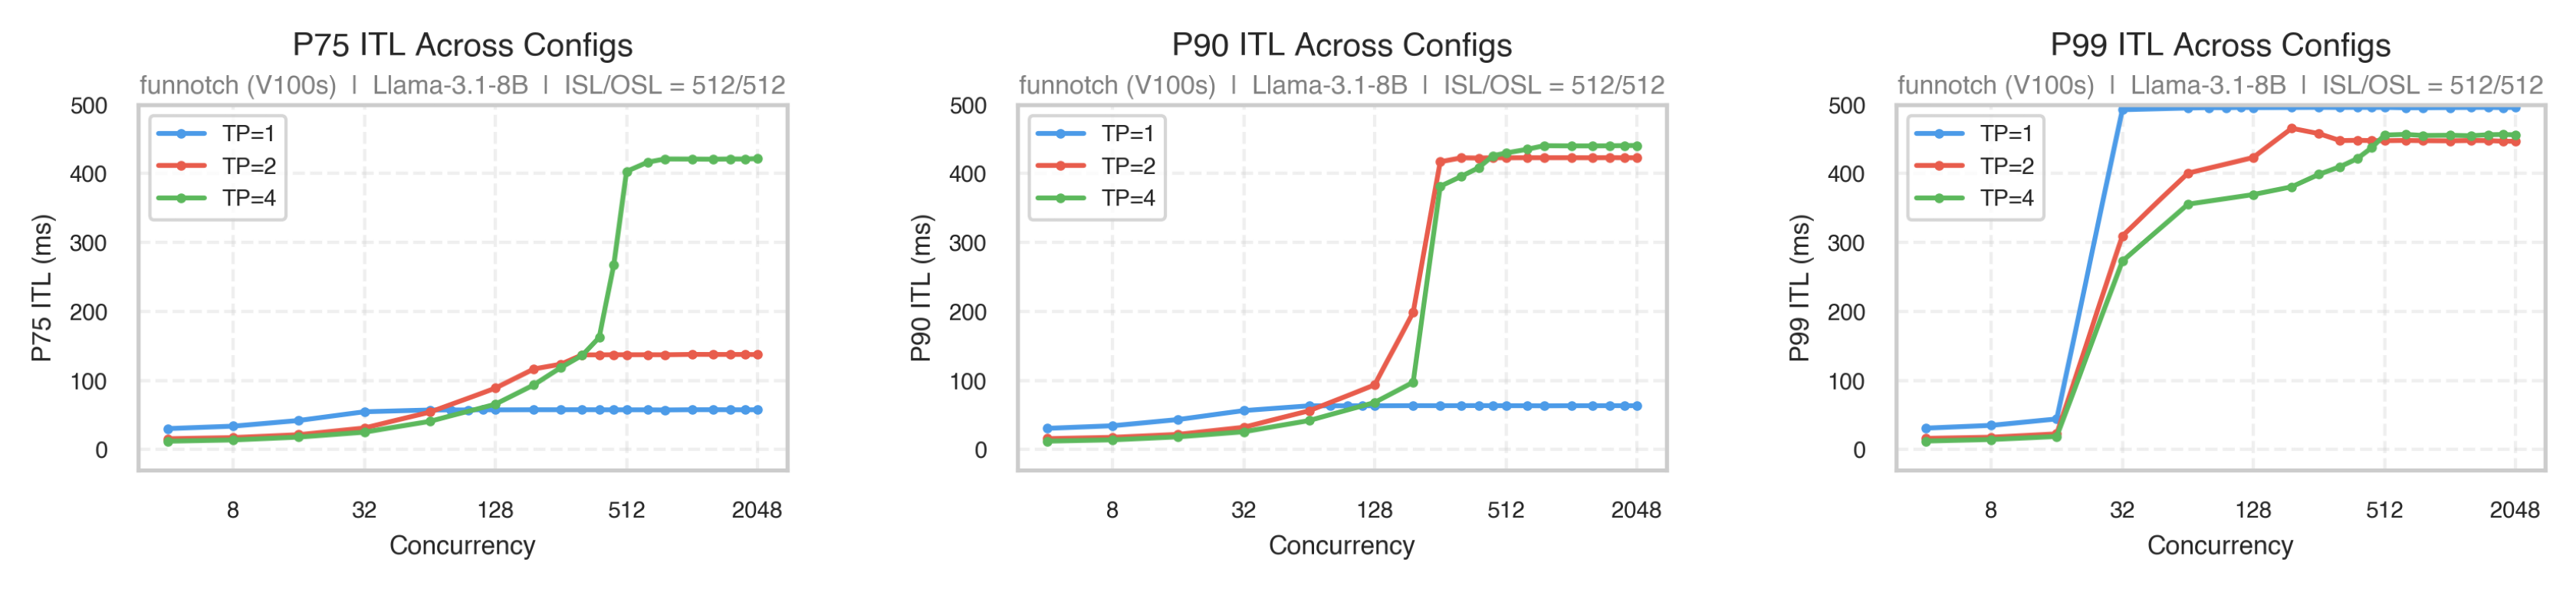

In [281]:
y_lim = [-30,500]
fig_p75_itl = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp4_a100_df],
    metric="p75_itl_ms",
    ylabel="P75 ITL (ms)",
    title="P75 ITL Across Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    y_lim=y_lim,
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_shyfec
)
fig_p90_itl = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp4_a100_df],
    metric="p90_itl_ms",
    ylabel="P90 ITL (ms)",
    title="P90 ITL Across Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    y_lim=y_lim,
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_shyfec
)
fig_p99_itl = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp4_a100_df],
    metric="p99_itl_ms",
    ylabel="P99 ITL (ms)",
    title="P99 ITL Across Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    y_lim=y_lim,
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_shyfec
)
show_side_by_side(fig_p75_itl, fig_p90_itl, fig_p99_itl)

fig_p75_itl = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp4_v100_df],
    metric="p75_itl_ms",
    ylabel="P75 ITL (ms)",
    title="P75 ITL Across Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    y_lim=y_lim,
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_funnotch
)
fig_p90_itl = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp4_v100_df],
    metric="p90_itl_ms",
    ylabel="P90 ITL (ms)",
    title="P90 ITL Across Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    y_lim=y_lim,
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_funnotch
)
fig_p99_itl = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp4_v100_df],
    metric="p99_itl_ms",
    ylabel="P99 ITL (ms)",
    title="P99 ITL Across Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    y_lim=y_lim,
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_funnotch
)
show_side_by_side(fig_p75_itl, fig_p90_itl, fig_p99_itl)

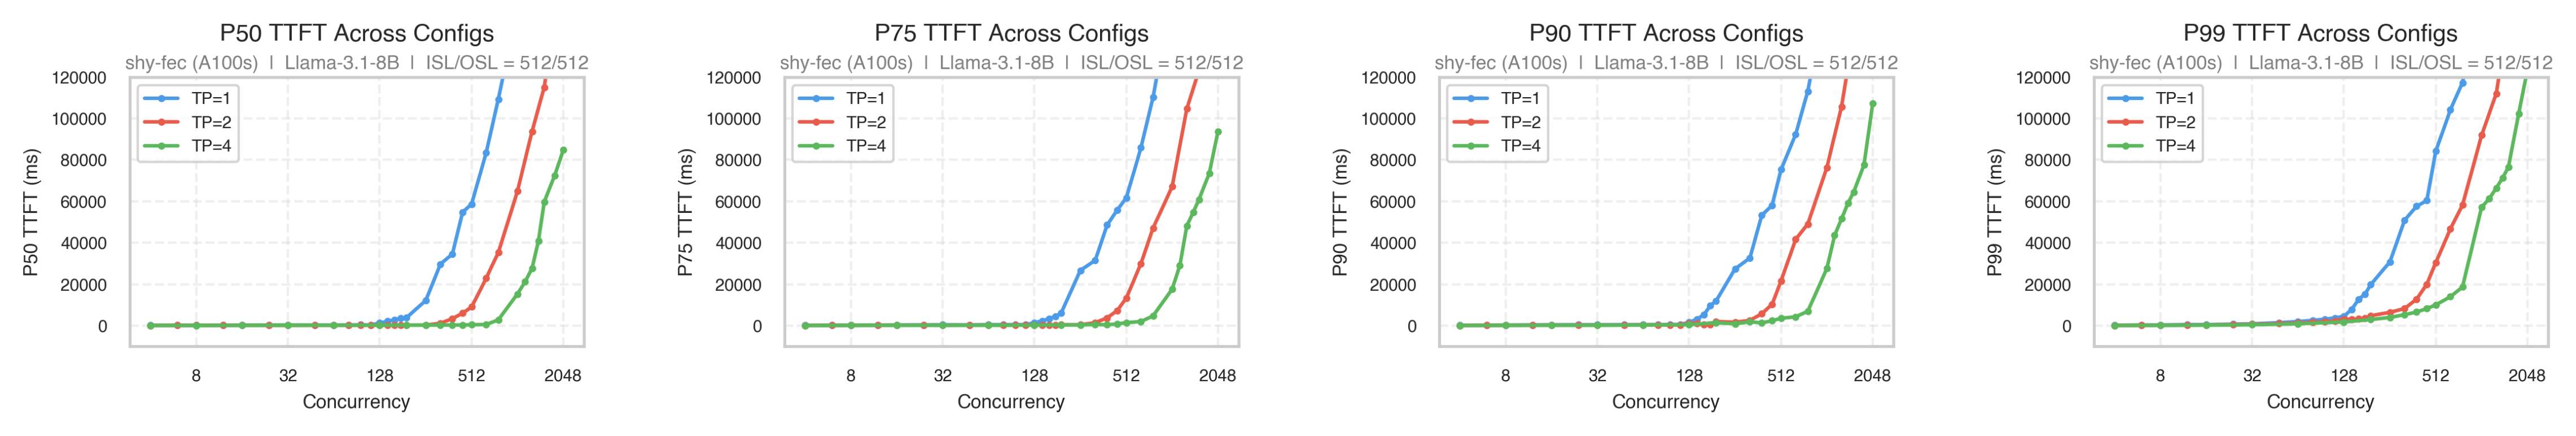

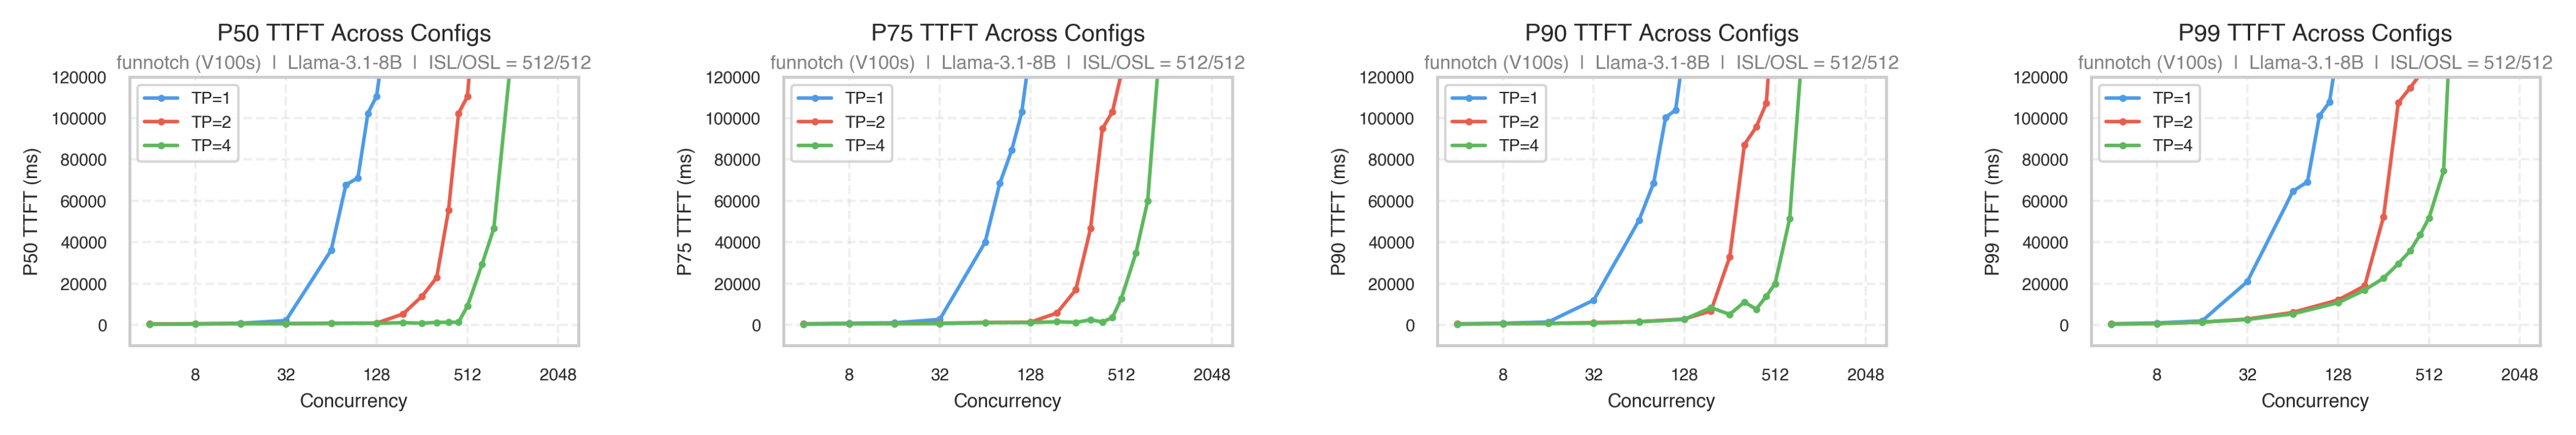

In [ ]:
y_lim = [-10000, 120000]
fig_p50_ttft = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp4_a100_df],
    metric="median_ttft_ms",
    ylabel="P50 TTFT (ms)",
    title="P50 TTFT Across Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    y_lim=y_lim,
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_shyfec
)
fig_p75_ttft = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp4_a100_df],
    metric="p75_ttft_ms",
    ylabel="P75 TTFT (ms)",
    title="P75 TTFT Across Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    y_lim=y_lim,
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_shyfec
)
fig_p90_ttft = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp4_a100_df],
    metric="p90_ttft_ms",
    ylabel="P90 TTFT (ms)",
    title="P90 TTFT Across Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    y_lim=y_lim,
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_shyfec
)
fig_p99_ttft = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp4_a100_df],
    metric="p99_ttft_ms",
    ylabel="P99 TTFT (ms)",
    title="P99 TTFT Across Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    y_lim=y_lim,
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_shyfec
)
show_side_by_side(fig_p50_ttft,fig_p75_ttft, fig_p90_ttft, fig_p99_ttft)

fig_p50_ttft = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp4_v100_df],
    metric="median_ttft_ms",
    ylabel="P50 TTFT (ms)",
    title="P50 TTFT Across Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    y_lim=y_lim,
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_funnotch
)
fig_p75_ttft = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp4_v100_df],
    metric="p75_ttft_ms",
    ylabel="P75 TTFT (ms)",
    title="P75 TTFT Across Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    y_lim=y_lim,
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_funnotch
)
fig_p90_ttft = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp4_v100_df],
    metric="p90_ttft_ms",
    ylabel="P90 TTFT (ms)",
    title="P90 TTFT Across Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    y_lim=y_lim,
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_funnotch
)
fig_p99_ttft = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp4_v100_df],
    metric="p99_ttft_ms",
    ylabel="P99 TTFT (ms)",
    title="P99 TTFT Across Configs",
    labels=["TP=1", "TP=2", "TP=4"],
    y_lim=y_lim,
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_funnotch
)
show_side_by_side(fig_p50_ttft, fig_p75_ttft, fig_p90_ttft, fig_p99_ttft)

  config  gpu  tp  capacity  throughput    p90_ttft    p90_itl  ttft_headroom  itl_headroom status
v100_tp1 V100   1        16  341.735232 1369.724577  43.299113    8630.275423    356.700887     OK
v100_tp2 V100   2       192 1243.513752 6688.996567 198.714070    3311.003433    201.285930     OK
v100_tp4 V100   4       256 1710.298806 5025.789561 381.429168    4974.210439     18.570832     OK
a100_tp1 A100   1       128 3075.982196 1553.115861  32.718022    8446.884139    367.281978     OK
a100_tp2 A100   2       256 5823.733036 1616.541980 114.456667    8383.458020    285.543333     OK
a100_tp4 A100   4       384 9215.517044 1309.588340  88.617438    8690.411660    311.382562     OK


Text(0.5, -0.7500000000000178, 'GPU Type')

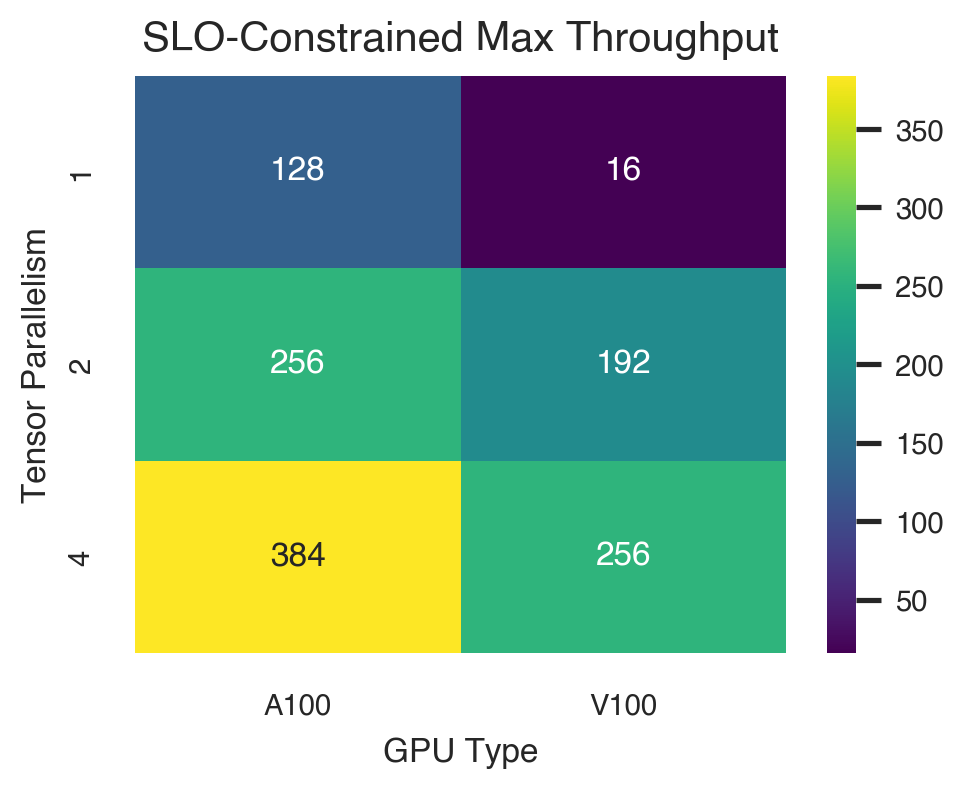

In [330]:
ITL_SLO = 400       # ms
TTFT_SLO = 10000     # ms 

results = []

results.append(extract_optimal_point(tp1_v100_df, "v100_tp1", "V100", 1, ITL_SLO, TTFT_SLO))
results.append(extract_optimal_point(tp2_v100_df, "v100_tp2", "V100", 2, ITL_SLO, TTFT_SLO))
# results.append(extract_optimal_point(tp2_v100_shm_df, "v100_tp2_shm", "V100", 2, ITL_SLO, TTFT_SLO))
results.append(extract_optimal_point(tp4_v100_df, "v100_tp4", "V100", 4, ITL_SLO, TTFT_SLO))

results.append(extract_optimal_point(tp1_a100_df, "a100_tp1", "A100", 1, ITL_SLO, TTFT_SLO))
results.append(extract_optimal_point(tp2_a100_df, "a100_tp2", "A100", 2, ITL_SLO, TTFT_SLO))
# results.append(extract_optimal_point(tp2_a100_shm_df, "a100_tp2_shm", "A100", 2, ITL_SLO, TTFT_SLO))
# results.append(extract_optimal_point(tp2_a100_nwfb_df, "a100_tp2_nwfb", "A100", 2, ITL_SLO, TTFT_SLO))
results.append(extract_optimal_point(tp4_a100_df, "a100_tp4", "A100", 4, ITL_SLO, TTFT_SLO))

summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))
pivot = summary_df.pivot(index="tp", columns="gpu", values="capacity")

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="viridis")
plt.title("SLO-Constrained Max Throughput")
plt.ylabel("Tensor Parallelism")
plt.xlabel("GPU Type")

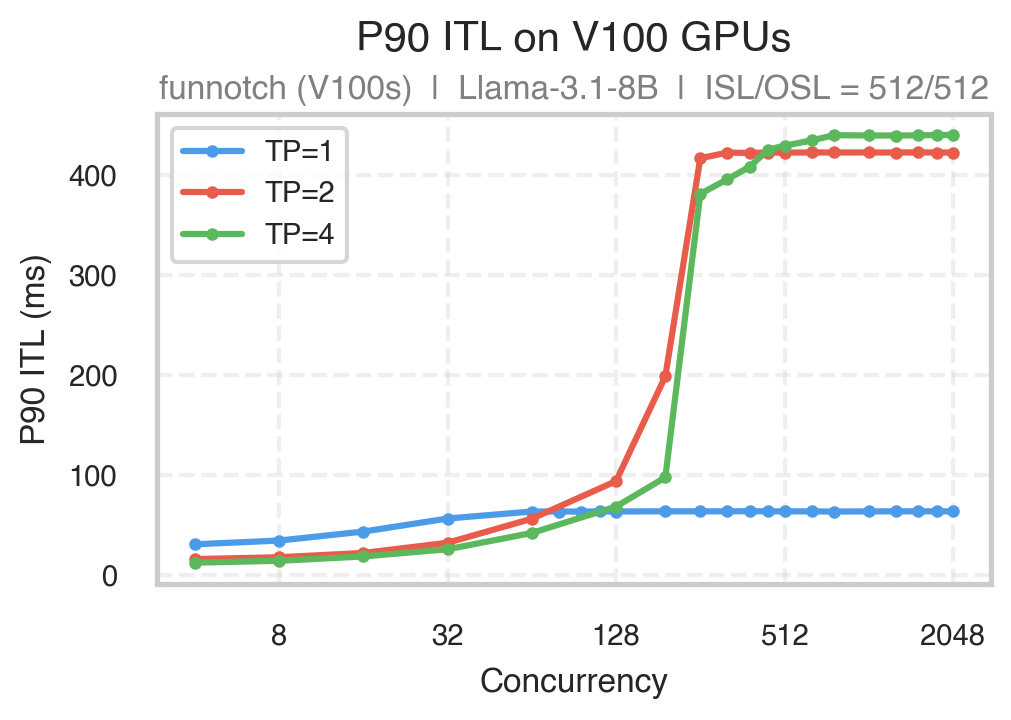

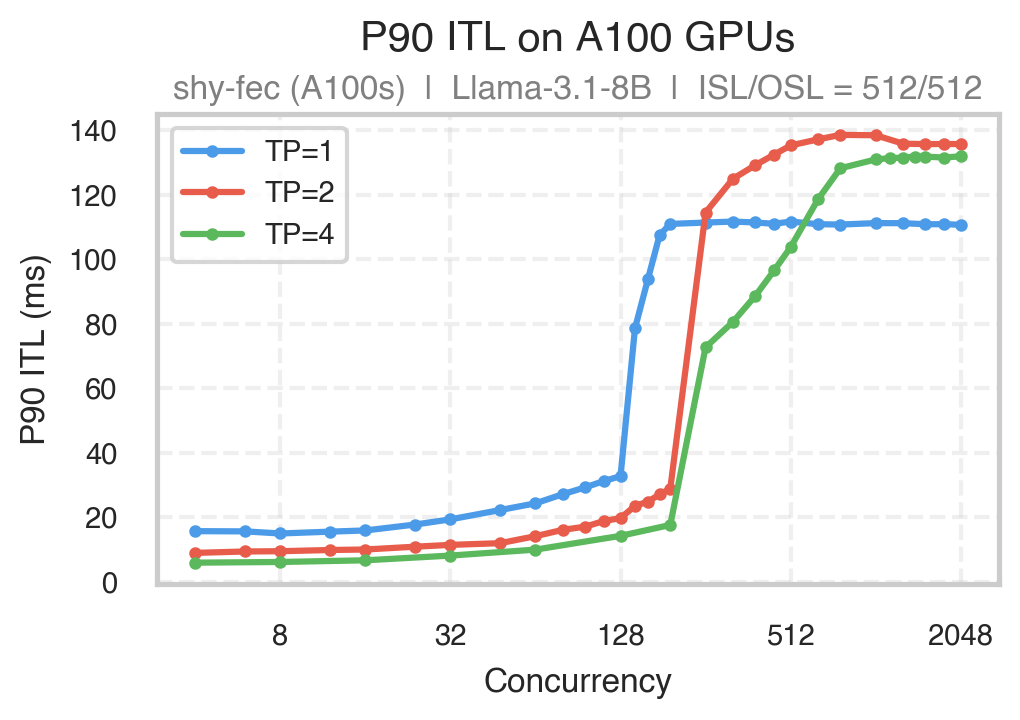

In [325]:
# fig_p90_ttft = plot_metric_vs_concurrency(
#     [tp1_v100_df, tp2_v100_df, tp4_v100_df],
#     metric="p90_ttft_ms",
#     ylabel="P90 TTFT",
#     title="P90 TTFT on V100 GPUs",
#     labels=["TP=1", "TP=2", "TP=4"],
#     log_scale=True,
#     colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
#     subtitle_info=sub_funnotch
# )
# fig_p90_ttft = plot_metric_vs_concurrency(
#     [tp1_a100_df, tp2_a100_df, tp4_a100_df],
#     metric="p90_ttft_ms",
#     ylabel="P90 TTFT",
#     title="P90 TTFT on A100 GPUs",
#     labels=["TP=1", "TP=2", "TP=4"],
#     log_scale=True,
#     colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
#     subtitle_info=sub_shyfec,
# )
fig_p90_itl = plot_metric_vs_concurrency(
    [tp1_v100_df, tp2_v100_df, tp4_v100_df],
    metric="p90_itl_ms",
    ylabel="P90 ITL (ms)",
    title="P90 ITL on V100 GPUs",
    labels=["TP=1", "TP=2", "TP=4"],
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_funnotch
)
fig_p90_itl = plot_metric_vs_concurrency(
    [tp1_a100_df, tp2_a100_df, tp4_a100_df],
    metric="p90_itl_ms",
    ylabel="P90 ITL (ms)",
    title="P90 ITL on A100 GPUs",
    labels=["TP=1", "TP=2", "TP=4"],
    colors=["#4C9BE8", "#E85C4C", "#5CB85C"],
    subtitle_info=sub_shyfec
)